# Librerías

In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.integrate import dblquad, quad
from scipy.integrate import solve_ivp, simpson


mpl.rc('figure', figsize=(12, 6))
mpl.rc('text', usetex = False)
mpl.rc('font', family = 'serif')
mpl.rc('font', size = '14')
mpl.rc('xtick', labelsize=14) 
mpl.rc('ytick', labelsize=14)
mpl.rcParams['mathtext.fontset'] = 'stix'

Para un modelo de preheating con $V(\phi) = \lambda \phi^4$ tenemos que las ecuaciones dinámicas adimensionales para el background son:

$$\begin{cases}
    \displaystyle \frac{d^2 \tilde{\phi}}{d \tilde{t}^2} + \frac{3}{a} \frac{d a}{d \tilde{t}} \frac{d \tilde{\phi}}{d \tilde{t}} + \tilde{\phi}^3 &= 0  \\ \\
    \displaystyle \frac{d^2 a}{d \tilde{t}^2} + \frac{a}{3} \left[ \left( \frac{d \tilde{\phi}}{d \tilde{t}} \right)^2 - \frac{\tilde{\phi}^4}{4} \right] &= 0
\end{cases} \tag{1}$$

Y para las perturbaciones, las ecuaciones adimensionales son:

$$\begin{cases}
    \displaystyle \frac{d^2 \delta \tilde{\phi}_k}{d \tilde{t}^2} + \frac{3}{a} \frac{d a}{d \tilde{t}} \frac{d \tilde{\phi}_k}{d \tilde{t}} + \left( \frac{\tilde{k}^2}{a^2} + 3 \tilde{\phi}^2 \right) \delta \tilde{\phi}_k &= 0\\
    \displaystyle \frac{d^2 \tilde{\chi}_k}{d \tilde{t}^2} + \frac{3}{a} \frac{d a}{d \tilde{t}} \frac{d \tilde{\chi}_k}{d \tilde{t}} + \left( \frac{\tilde{k}^2}{a^2} + g^2 \tilde{\phi}^2 \right) \tilde{\chi}_k &= 0
\end{cases} \tag{2}$$

# Dinámica 1

Usar $\tilde{\chi}_k = \phi_0^2 \lambda^{3/2} \chi_k$

## Sin expansión

### Background

In [2]:
def background(t, y):
    phi, phi_dot = y
    
    # Ecuación para φ
    phi_ddot = - phi **3

    return [phi_dot, phi_ddot]

In [3]:
# Rango de tiempo de integración
t0, tf = 0, 100
t_eval = np.linspace(t0, tf, int(1e4))

# Condiciones iniciales
# Background
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2/np.sqrt(2)

y0 = [phi0, phi_dot0]

In [4]:
# Resolvamos el sistema acoplado
sol = solve_ivp(background, [t0, tf], y0, args=(), t_eval=t_eval, method = "RK45", rtol=1e-8, atol=1e-8)

# Extraemos los resultados
phi_sol = sol.y[0]

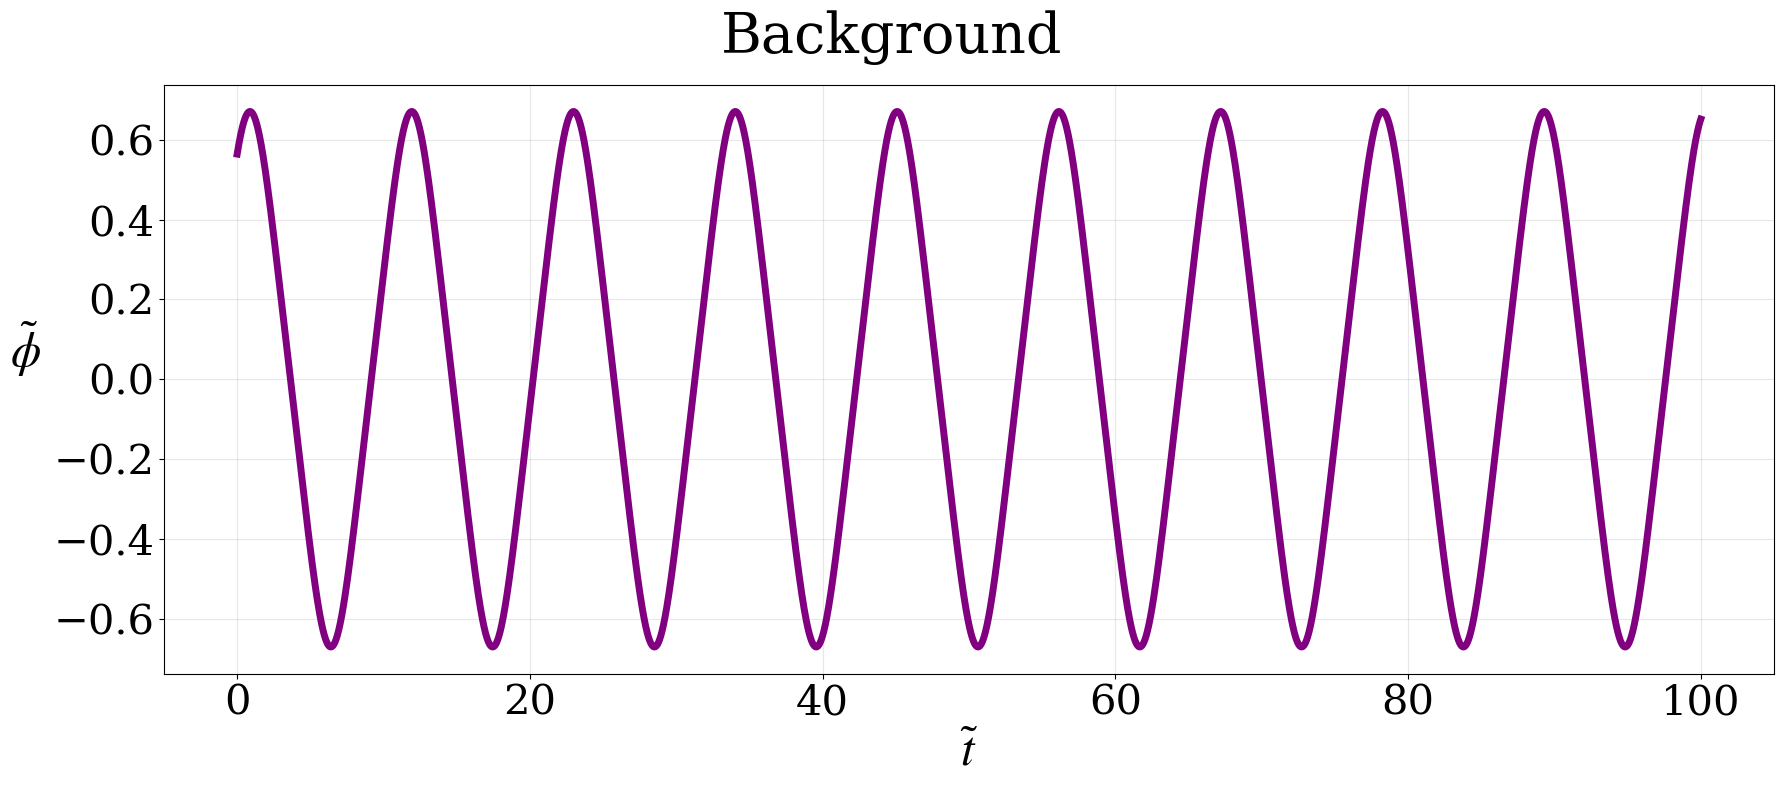

In [5]:
plt.figure(figsize = (18, 8))

plt.plot(sol.t, phi_sol, lw = 5, color = "purple")
plt.ylabel(r"$\tilde{\phi}$", labelpad = 20, rotation = "horizontal", fontsize = 35)
plt.xlabel(r"$\tilde{t}$", fontsize = 35)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.grid(alpha = 0.3)

plt.suptitle("Background", fontsize = 40)
plt.tight_layout()
plt.show()

### Perturbaciones

In [6]:
# Armemos un código para graficar las perturbaciones
def pert(t, y, k, g):
    phi, phi_dot, dphi_k, dphi_dot_k, chi_k, chi_dot_k = y
    
    # Ecuación para φ
    phi_ddot = - phi **3
    
    # Ecuaciones para δφ_k
    dphi_ddot_k = - (k**2 / 1 + 3 * phi**2) * dphi_k
    
    # Ecuaciones para χ_k
    chi_ddot_k = - (k**2 + g**2 * phi**2) * chi_k
    
    return [phi_dot, phi_ddot, dphi_dot_k, dphi_ddot_k, chi_dot_k, chi_ddot_k]

In [7]:
# Parámetros físicos
k = 1
g = 1e-2

# Rango de tiempo de integración
t0, tf = 0, 100
t_eval = np.linspace(t0, tf, int(1e4))

# Condiciones iniciales
# Background
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2/np.sqrt(2)
# Perturbaciones
Omega_phi = k**2+ 3 * phi0**2
Omega_chi = k**2 + g**2 * phi0**2
dphi_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))
dphi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))
chi_k0 = 0
chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))

y0 = [phi0, phi_dot0, dphi_k0, dphi_dot_k0, chi_k0, chi_dot_k0]

In [8]:
# Resolvamos el sistema acoplado
sol = solve_ivp(pert, [t0, tf], y0, args=(k, g), t_eval=t_eval, method = "RK45", rtol=1e-8, atol=1e-8)

# Extraemos los resultados
dphi_sol = sol.y[2]
chi_sol = sol.y[4]

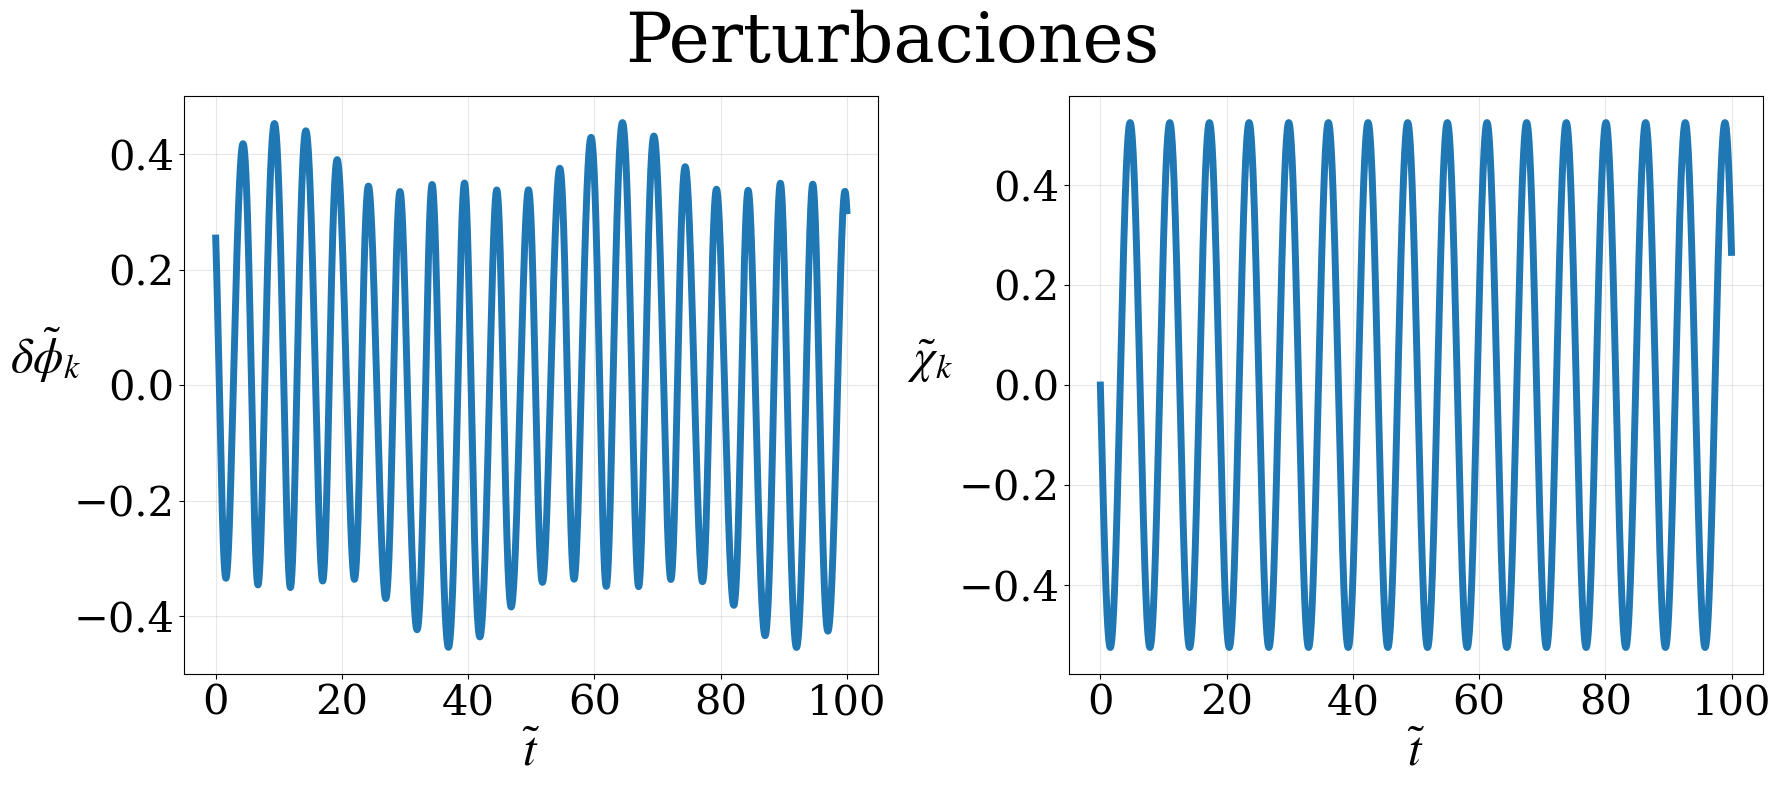

In [9]:
plt.figure(figsize = (18, 8))

plt.subplot(1,2,1)
plt.plot(sol.t, dphi_sol, lw = 5)
plt.ylabel(r"$\delta \tilde{\phi}_k$", labelpad = 20, rotation = "horizontal", fontsize = 35)
plt.xlabel(r"$\tilde{t}$", fontsize = 35)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.grid(alpha = 0.3)

plt.subplot(1,2,2)
plt.plot(sol.t, chi_sol, lw = 5)
plt.ylabel(r"$\tilde{\chi}_k$", labelpad = 20, rotation = "horizontal", fontsize = 35)
plt.xlabel(r"$\tilde{t}$", fontsize = 35)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.grid(alpha = 0.3)

plt.suptitle("Perturbaciones", fontsize = 50)
plt.tight_layout()
plt.show()

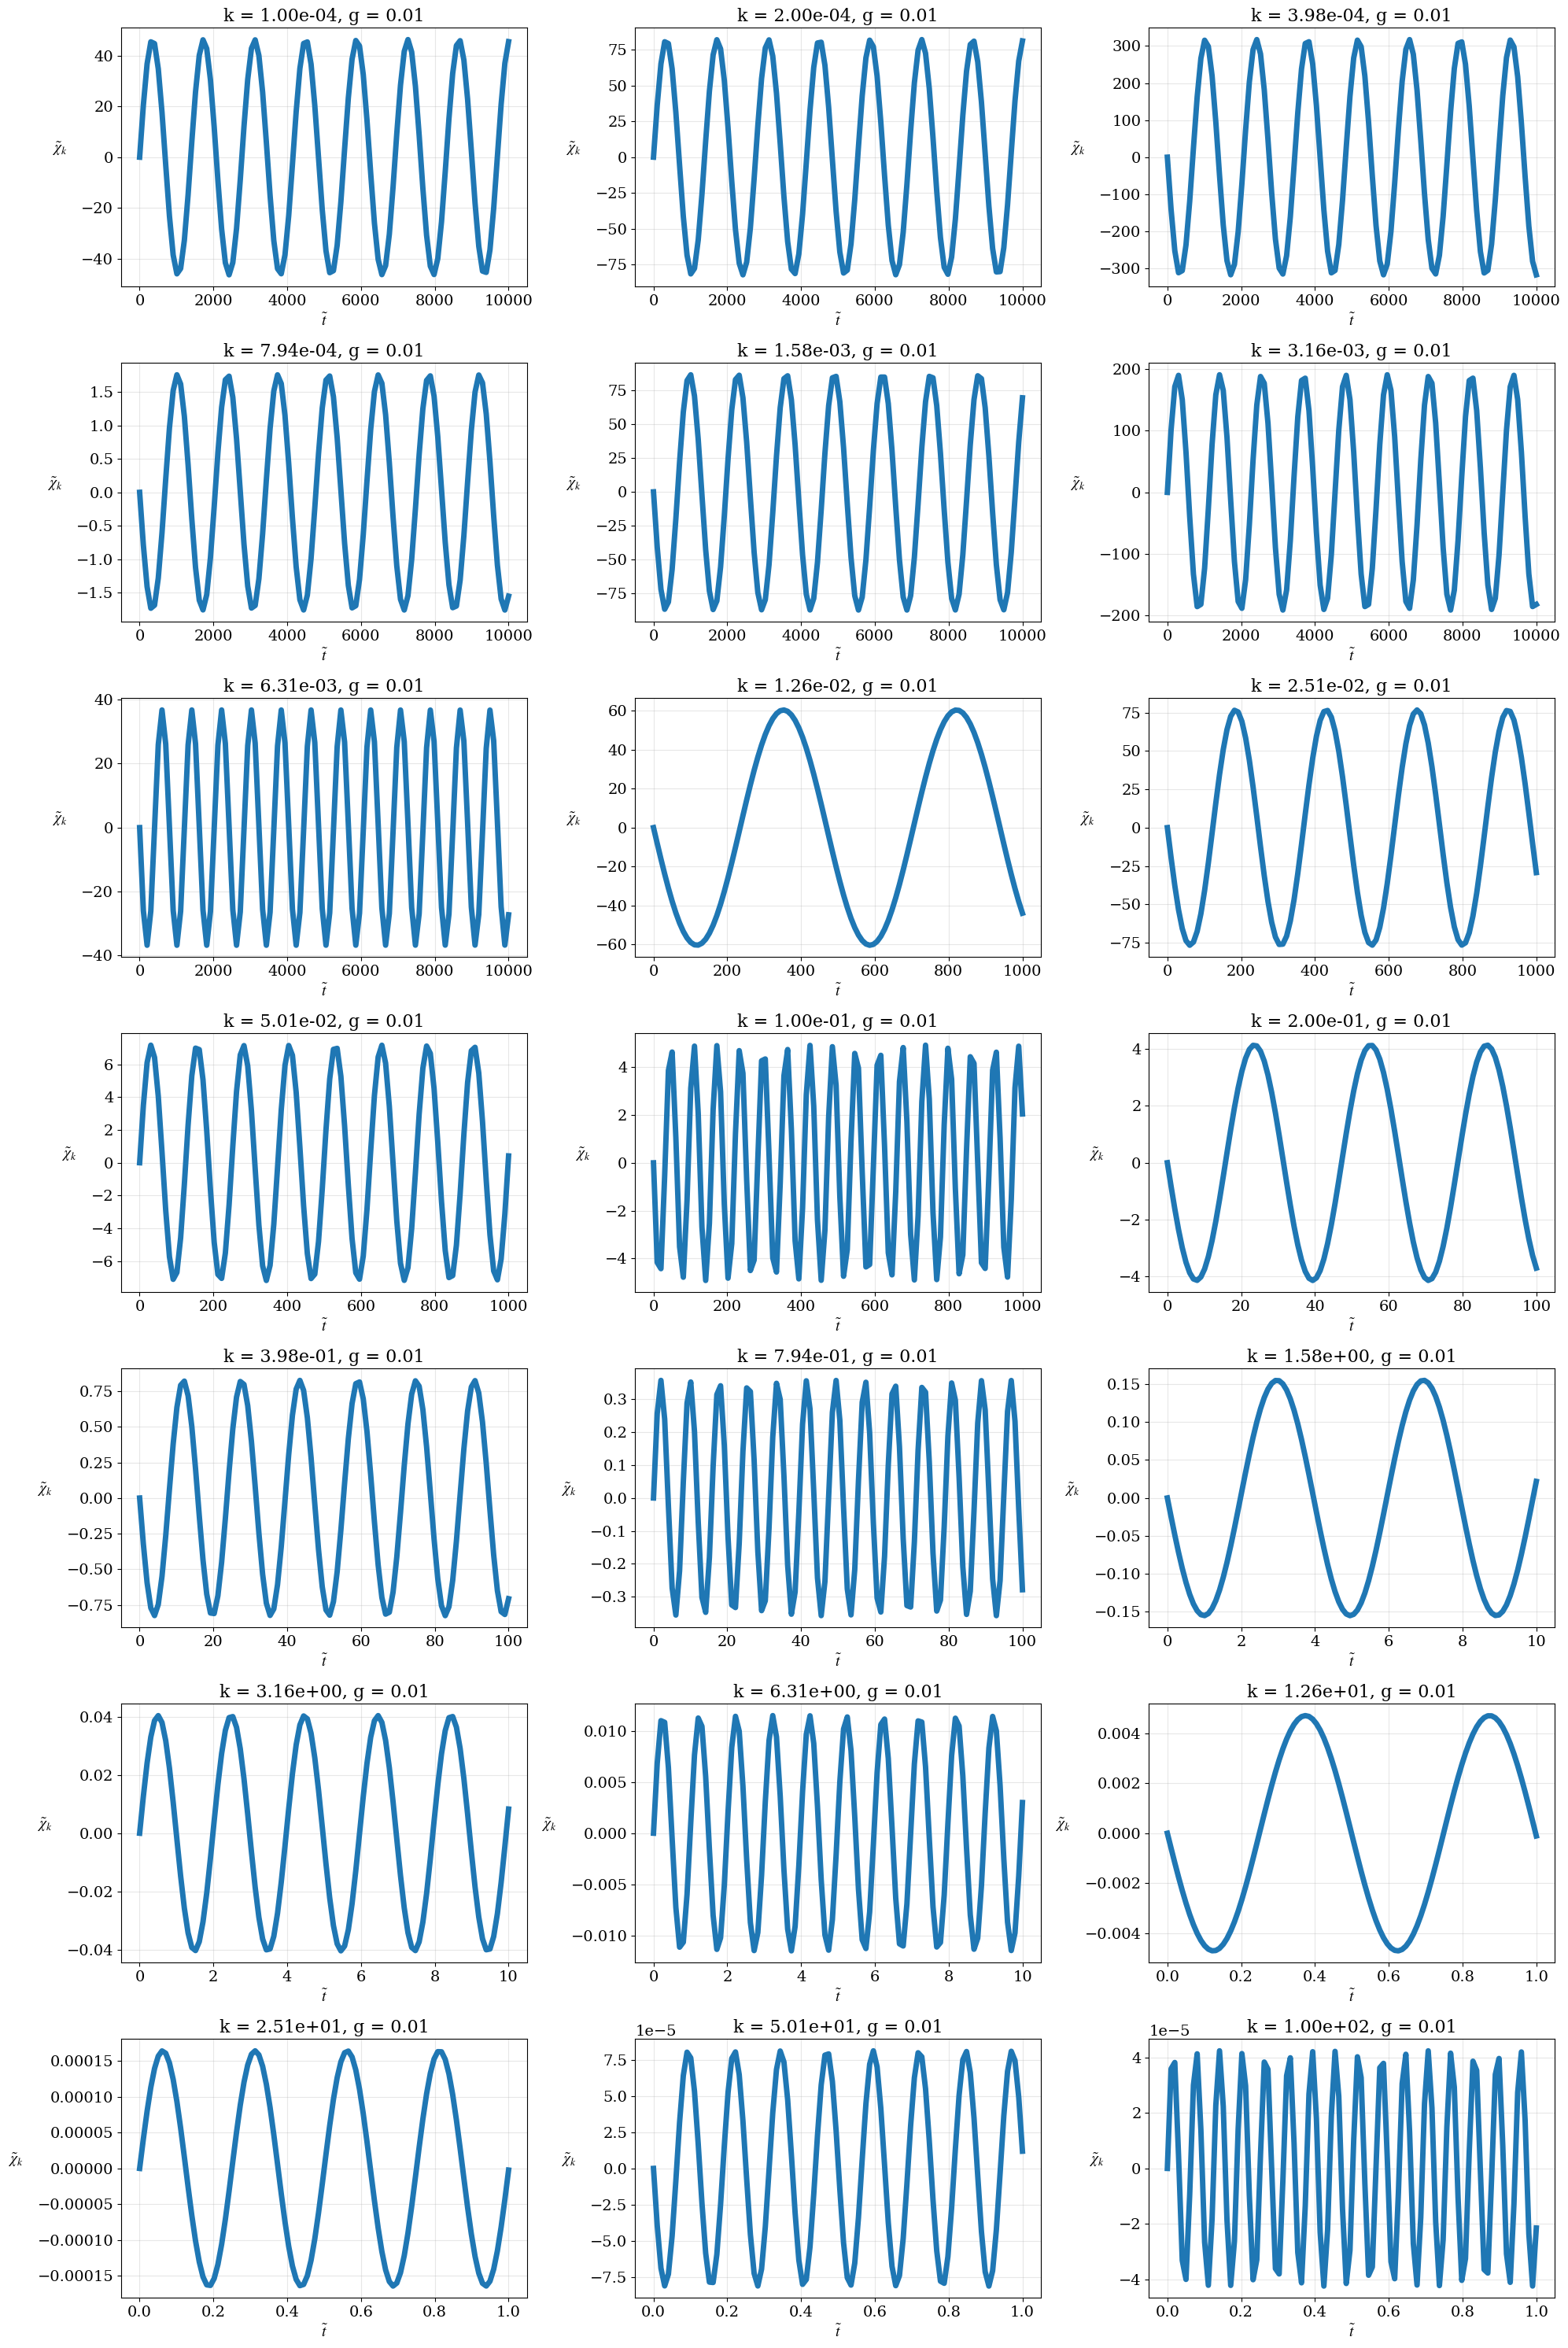

In [10]:
# Ahora veamos qué pasa para las amplitudes de chi de los modos para distintos valores de k

# Parámetros físicos
K = np.logspace(-4, 2, num=21)
g = 1e-2

# Rango de tiempo de integración
t0, tf = 0, [1e4,1e4,1e4,1e4,1e4,1e4,1e4,1e3,1e3,1e3,1e3,1e2,1e2,1e2,10,10,10,1,1,1,1]

# Condiciones iniciales
# Background
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2/np.sqrt(2)

plt.figure(figsize = (20, 30))
i = 0

for k in K:
    t_eval = np.linspace(t0, tf[i], int(1e2))

    # Perturbaciones
    Omega_phi = k**2+ 3 * phi0**2
    Omega_chi = k**2 + g**2 * phi0**2
    dphi_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))
    dphi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))
    chi_k0 = 0
    chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))

    y0 = [phi0, phi_dot0, dphi_k0, dphi_dot_k0, chi_k0, chi_dot_k0]

    # Resolvamos el sistema acoplado
    sol = solve_ivp(pert, [t0, tf[i]], y0, args=(k, g), t_eval=t_eval, method = "RK45", rtol=1e-8, atol=1e-8)

    # Extraemos los resultados
    chi_sol = sol.y[4]
    i = i + 1

    plt.subplot(7,3,i)
    plt.plot(sol.t, chi_sol, lw = 5)
    plt.ylabel(r"$\tilde{\chi}_k$", labelpad = 20, rotation = "horizontal")
    plt.xlabel(r"$\tilde{t}$")
    plt.grid(alpha = 0.3)
    plt.title(f"k = {k:.2e}, g = {g}")

plt.tight_layout()
plt.show()

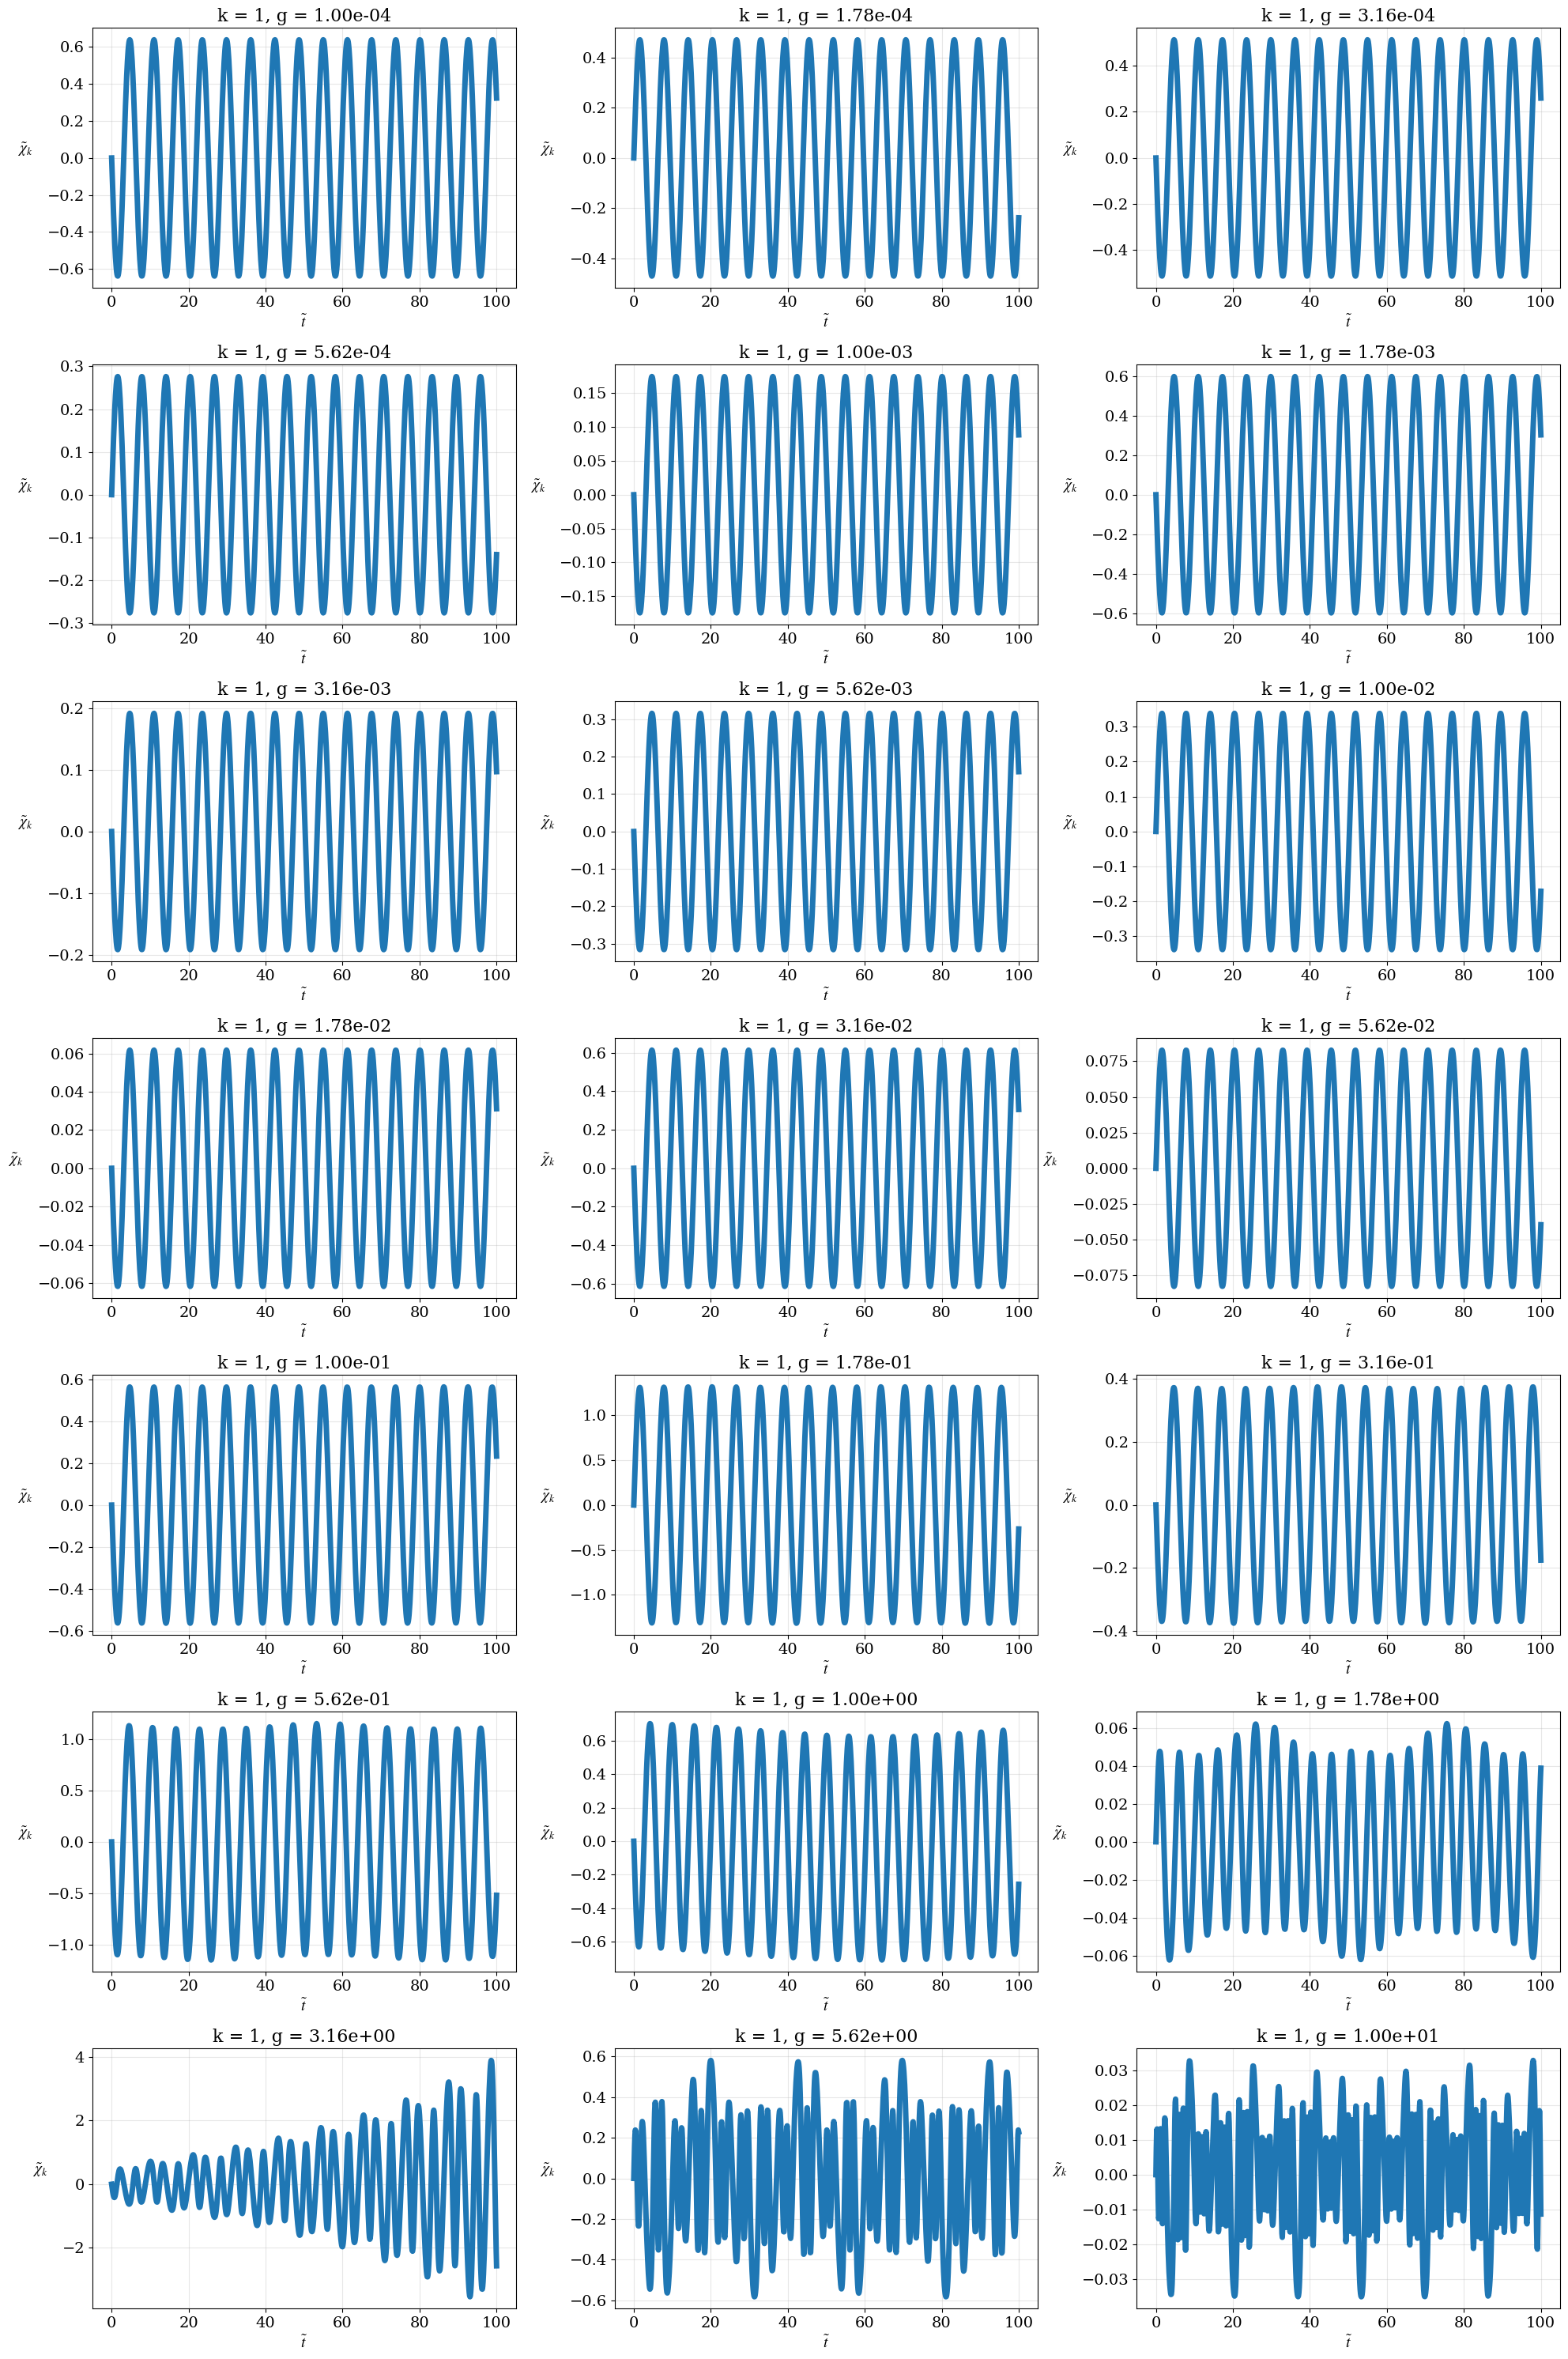

In [11]:
# Ahora veamos qué pasa para las amplitudes de chi de los modos para distintos valores de g

# Parámetros físicos
k = 1
G = np.logspace(-4,1,num=21)

# Rango de tiempo de integración
t0, tf = 0, 100

# Condiciones iniciales
# Background
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2/np.sqrt(2)

plt.figure(figsize = (20, 30))
i = 0

for g in G:
    t_eval = np.linspace(t0, tf, int(1e3))

    # Perturbaciones
    Omega_phi = k**2+ 3 * phi0**2
    Omega_chi = k**2 + g**2 * phi0**2
    dphi_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))
    dphi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))
    chi_k0 = 0
    chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))

    y0 = [phi0, phi_dot0, dphi_k0, dphi_dot_k0, chi_k0, chi_dot_k0]

    # Resolvamos el sistema acoplado
    sol = solve_ivp(pert, [t0, tf], y0, args=(k, g), t_eval=t_eval, method = "Radau", rtol=1e-8, atol=1e-8)

    # Extraemos los resultados
    chi_sol = sol.y[4]
    i = i + 1

    plt.subplot(7,3,i)
    plt.plot(sol.t, chi_sol, lw = 5)
    plt.ylabel(r"$\tilde{\chi}_k$", labelpad = 20, rotation = "horizontal")
    plt.xlabel(r"$\tilde{t}$")
    plt.grid(alpha = 0.3)
    plt.title(f"k = {k}, g = {g:.2e}")

plt.tight_layout()
plt.show()

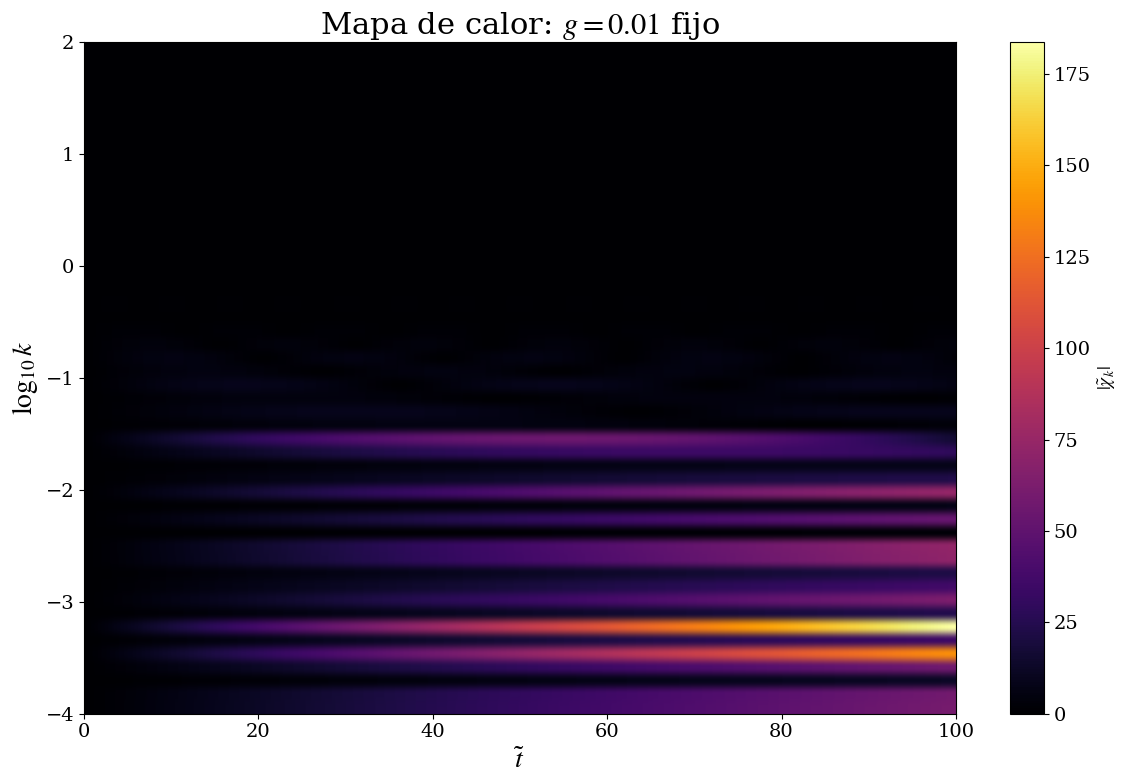

In [12]:
# Armemos tablas de instabilidad cómo las que armamos para la ecuación de Mathieu
# Parámetros
g = 1e-2  # g fijo
K = np.logspace(-4, 2, num=50)  # valores de k (eje y)
t0, tf = 0, 100
t_eval = np.linspace(t0, tf, 500)  # eje x (tiempo)

# Condiciones iniciales background
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2/np.sqrt(2)

# Prealoca matriz para amplitudes
chi_matrix = np.zeros((len(K), len(t_eval)))

for i, k in enumerate(K):
    Omega_phi = k**2 + 3 * phi0**2
    dphi_k0 = np.random.normal(loc=0, scale=1/(np.sqrt(2 * Omega_phi)))
    dphi_dot_k0 = np.random.normal(loc=0, scale=1/(np.sqrt(2 * Omega_phi)))
    chi_k0 = 0
    chi_dot_k0 = np.random.normal(loc=0, scale=1/(np.sqrt(2 * Omega_phi)))
    y0 = [phi0, phi_dot0, dphi_k0, dphi_dot_k0, chi_k0, chi_dot_k0]
    sol = solve_ivp(pert, [t0, tf], y0, args=(k, g), t_eval=t_eval, method="RK45", rtol=1e-8, atol=1e-8)
    chi_matrix[i, :] = sol.y[4]  # amplitud de chi_k para cada t

# Graficar el mapa de calor
plt.figure(figsize=(12, 8))
extent = [t_eval[0], t_eval[-1], np.log10(K[0]), np.log10(K[-1])]
plt.imshow(np.abs(chi_matrix), aspect='auto', origin='lower', extent=extent, cmap='inferno')
plt.colorbar(label=r'$|\tilde{\chi}_k|$')
plt.xlabel(r'$\tilde{t}$', fontsize=20)
plt.ylabel(r'$\log_{10} k$', fontsize=20)
plt.title(f'Mapa de calor: $g={g}$ fijo', fontsize=22)
plt.tight_layout()
plt.show()

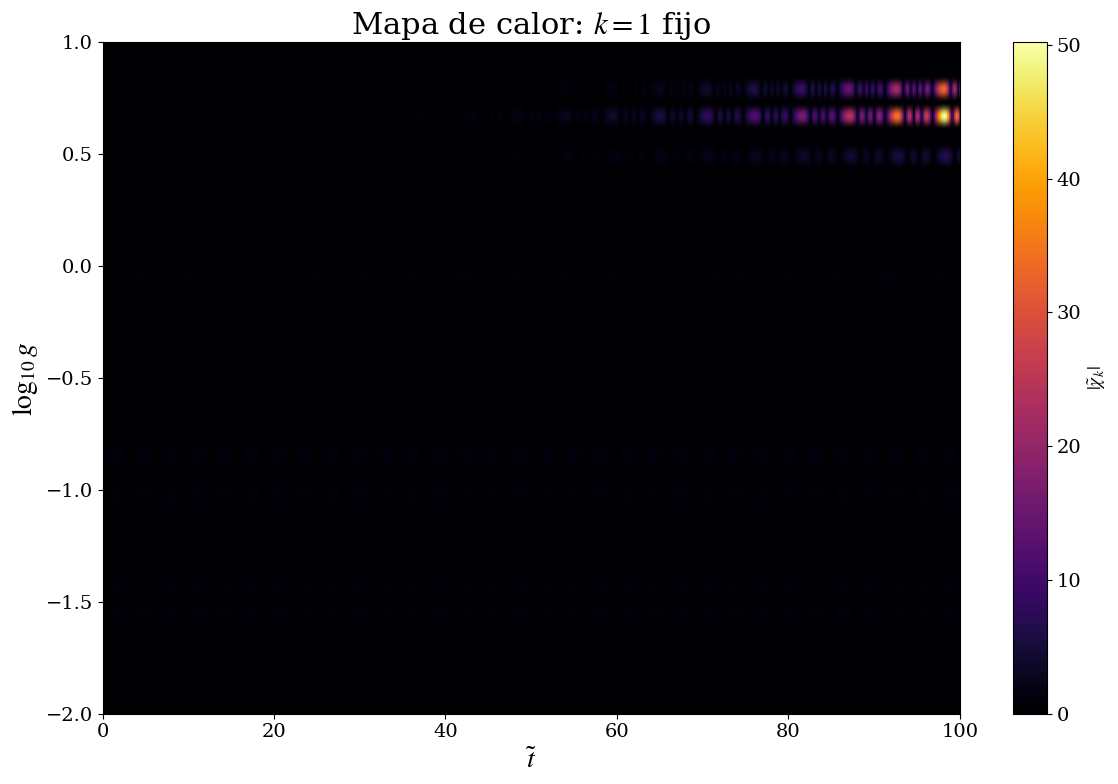

In [13]:
# Armemos tablas de instabilidad cómo las que armamos para la ecuación de Mathieu
# Parámetros
G = np.logspace(-2, 1, num=50)
k = 1  #Fijo
t0, tf = 0, 100
t_eval = np.linspace(t0, tf, 500)  # eje x (tiempo)

# Condiciones iniciales background
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2/np.sqrt(2)

# Prealoca matriz para amplitudes
chi_matrix = np.zeros((len(G), len(t_eval)))

for i, g in enumerate(G):
    Omega_phi = k**2 + 3 * phi0**2
    dphi_k0 = np.random.normal(loc=0, scale=1/(np.sqrt(2 * Omega_phi)))
    dphi_dot_k0 = np.random.normal(loc=0, scale=1/(np.sqrt(2 * Omega_phi)))
    chi_k0 = 0
    chi_dot_k0 = np.random.normal(loc=0, scale=1/(np.sqrt(2 * Omega_phi)))
    y0 = [phi0, phi_dot0, dphi_k0, dphi_dot_k0, chi_k0, chi_dot_k0]
    sol = solve_ivp(pert, [t0, tf], y0, args=(k, g), t_eval=t_eval, method="RK45", rtol=1e-8, atol=1e-8)
    chi_matrix[i, :] = sol.y[4]  # amplitud de chi_k para cada t

# Graficar el mapa de calor
plt.figure(figsize=(12, 8))
extent = [t_eval[0], t_eval[-1], np.log10(G[0]), np.log10(G[-1])]
plt.imshow(np.abs(chi_matrix), aspect='auto', origin='lower', extent=extent, cmap='inferno')
plt.colorbar(label=r'$|\tilde{\chi}_k|$')
plt.xlabel(r'$\tilde{t}$', fontsize=20)
plt.ylabel(r'$\log_{10} g$', fontsize=20)
plt.title(f'Mapa de calor: $k={k}$ fijo', fontsize=22)
plt.tight_layout()
plt.show()

## Con expansión

### Background

In [14]:
# Armemos un código que resuelva el background
def background(t, y):
    phi, phi_dot, a, a_dot = y
    
    # Evolución de a(t)
    a_ddot = - a/3 * (phi_dot**2 - phi**4/4)
    H = a_dot/a
    
    # Ecuación para φ
    phi_ddot = -3 * H * phi_dot - phi **3

    return [phi_dot, phi_ddot, a_dot, a_ddot]

In [15]:
# Rango de tiempo de integración
t0, tf = 0, 100
t_eval = np.linspace(t0, tf, int(1e4))

# Condiciones iniciales
# Background
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2/np.sqrt(2)
areh = 1
areh_dot = areh * phi0**2/(np.sqrt(6))

y0 = [phi0, phi_dot0, areh, areh_dot]

In [16]:
# Resolvamos el sistema acoplado
sol = solve_ivp(background, [t0, tf], y0, args=(), t_eval=t_eval, method = "RK45", rtol=1e-8, atol=1e-8)

# Extraemos los resultados
phi_sol = sol.y[0]
a_sol = sol.y[2]

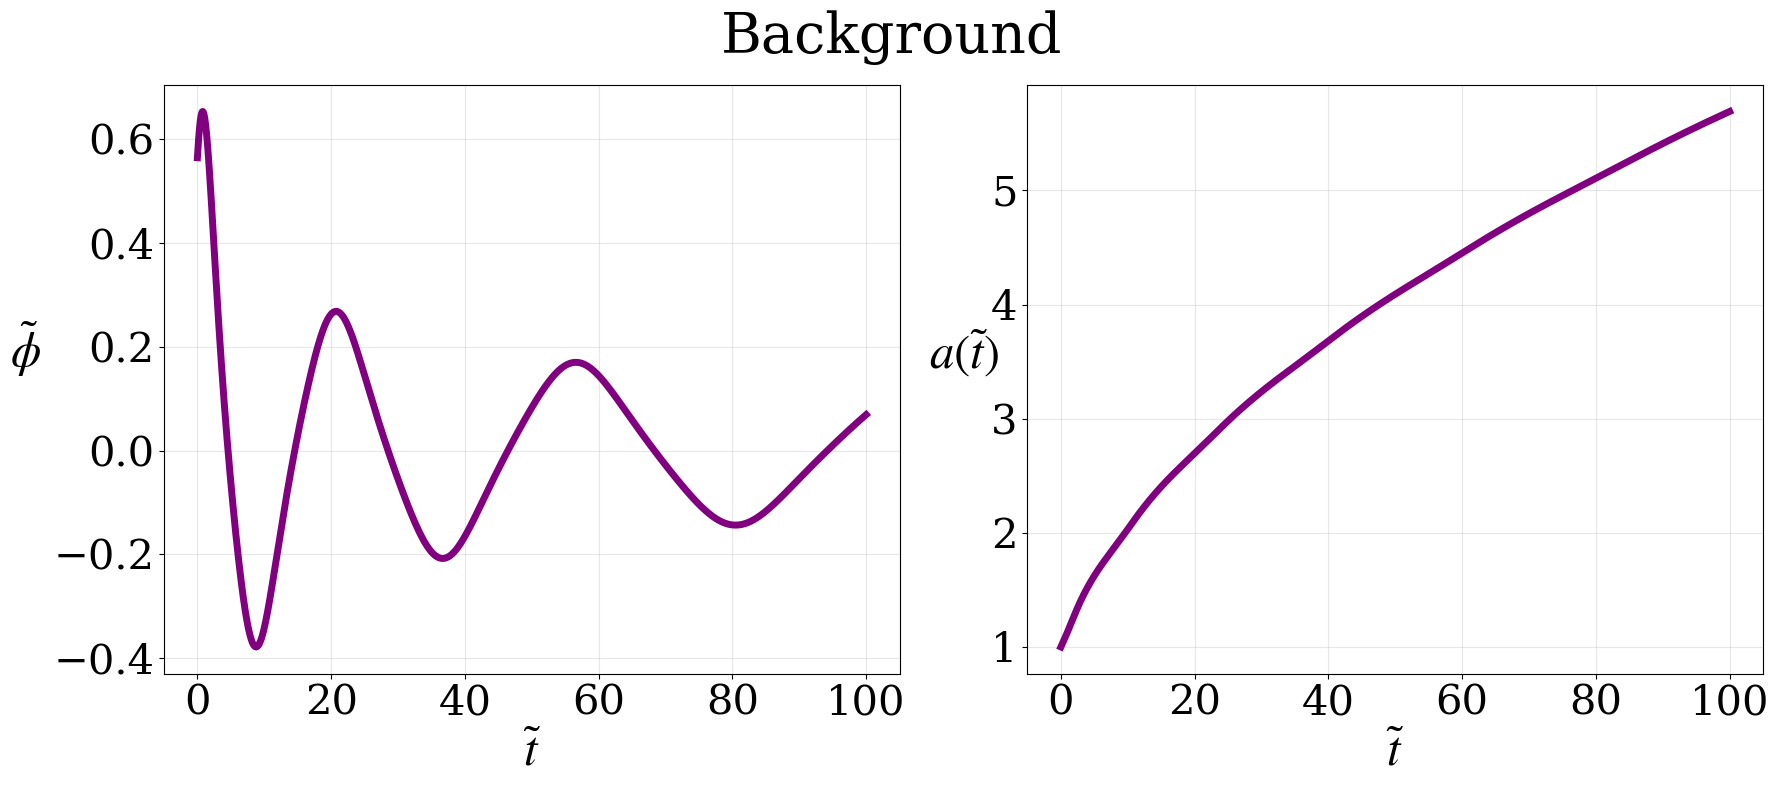

In [17]:
plt.figure(figsize = (18, 8))

plt.subplot(1,2,1)
plt.plot(sol.t, phi_sol, lw = 5, color = "purple")
plt.ylabel(r"$\tilde{\phi}$", labelpad = 20, rotation = "horizontal", fontsize = 35)
plt.xlabel(r"$\tilde{t}$", fontsize = 35)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.grid(alpha = 0.3)

plt.subplot(1,2,2)
plt.plot(sol.t, a_sol, lw = 5, color = "purple")
plt.ylabel(r"$a (\tilde{t})$", labelpad = 20, rotation = "horizontal", fontsize = 35)
plt.xlabel(r"$\tilde{t}$", fontsize = 35)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.grid(alpha = 0.3)

plt.suptitle("Background", fontsize = 40)
plt.tight_layout()
plt.show()

### Perturbaciones

In [18]:
# Armemos un código para graficar las perturbaciones
def pert(t, y, k, g):
    phi, phi_dot, dphi_k, dphi_dot_k, chi_k, chi_dot_k, a, a_dot = y

    # Evolución de a(t)
    a_ddot = - a/3 * (phi_dot**2 - phi**4/4)
    H = a_dot/a
    
    # Ecuación para φ
    phi_ddot = -3 * H * phi_dot - phi **3
    
    # Ecuaciones para δφ_k
    dphi_ddot_k = -3 * H * dphi_dot_k - (k**2 / a**2 + 3 * phi**2) * dphi_k
    
    # Ecuaciones para χ_k
    chi_ddot_k = -3 * H * chi_dot_k - (k**2 / a**2 + g**2 * phi**2) * chi_k
    
    return [phi_dot, phi_ddot, dphi_dot_k, dphi_ddot_k, chi_dot_k, chi_ddot_k, a_dot, a_ddot]

In [19]:
# Parámetros físicos
k = 1
g = 1e-2

# Rango de tiempo de integración
t0, tf = 0, 100
t_eval = np.linspace(t0, tf, int(1e4))

# Condiciones iniciales
# Background
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2/np.sqrt(2)
areh = 1
areh_dot = areh * phi0**2/(np.sqrt(6))
# Perturbaciones
Omega_phi = k**2/areh**2 + 3 * phi0**2
Omega_chi = k**2/areh**2 + g**2 * phi0**2
dphi_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))
dphi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))
chi_k0 = 0
chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))

y0 = [phi0, phi_dot0, dphi_k0, dphi_dot_k0, chi_k0, chi_dot_k0, areh, areh_dot]

In [20]:
# Resolvamos el sistema acoplado
sol = solve_ivp(pert, [t0, tf], y0, args=(k, g), t_eval=t_eval, method = "RK45", rtol=1e-8, atol=1e-8)

# Extraemos los resultados
dphi_sol = sol.y[2]
chi_sol = sol.y[4]

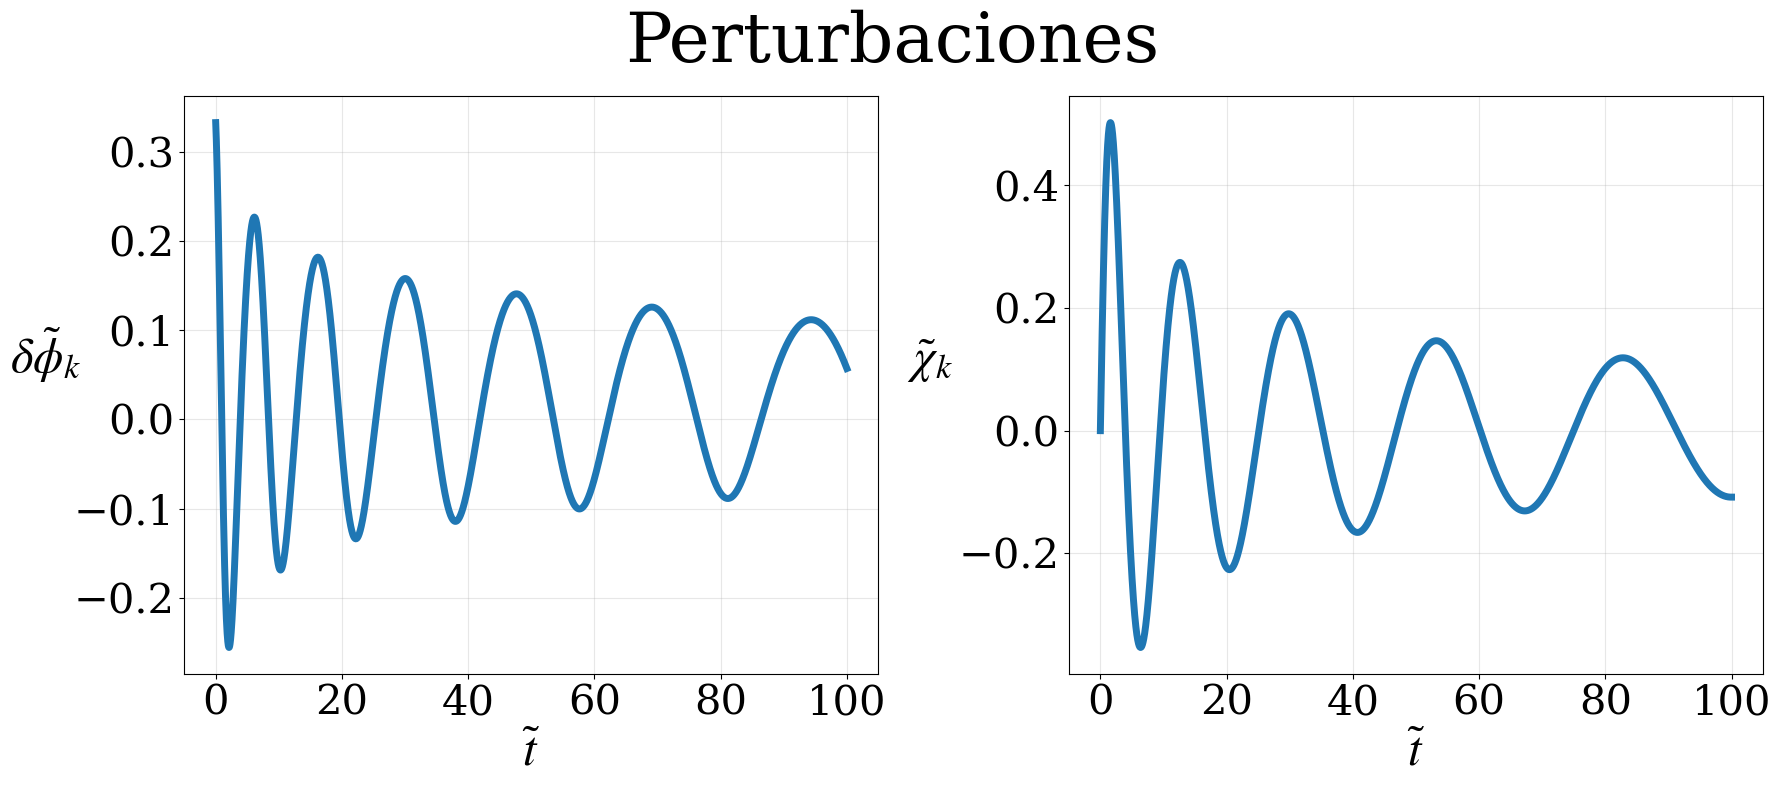

In [21]:
plt.figure(figsize = (18, 8))

plt.subplot(1,2,1)
plt.plot(sol.t, dphi_sol, lw = 5)
plt.ylabel(r"$\delta \tilde{\phi}_k$", labelpad = 20, rotation = "horizontal", fontsize = 35)
plt.xlabel(r"$\tilde{t}$", fontsize = 35)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.grid(alpha = 0.3)

plt.subplot(1,2,2)
plt.plot(sol.t, chi_sol, lw = 5)
plt.ylabel(r"$\tilde{\chi}_k$", labelpad = 20, rotation = "horizontal", fontsize = 35)
plt.xlabel(r"$\tilde{t}$", fontsize = 35)
plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.grid(alpha = 0.3)

plt.suptitle("Perturbaciones", fontsize = 50)
plt.tight_layout()
plt.show()

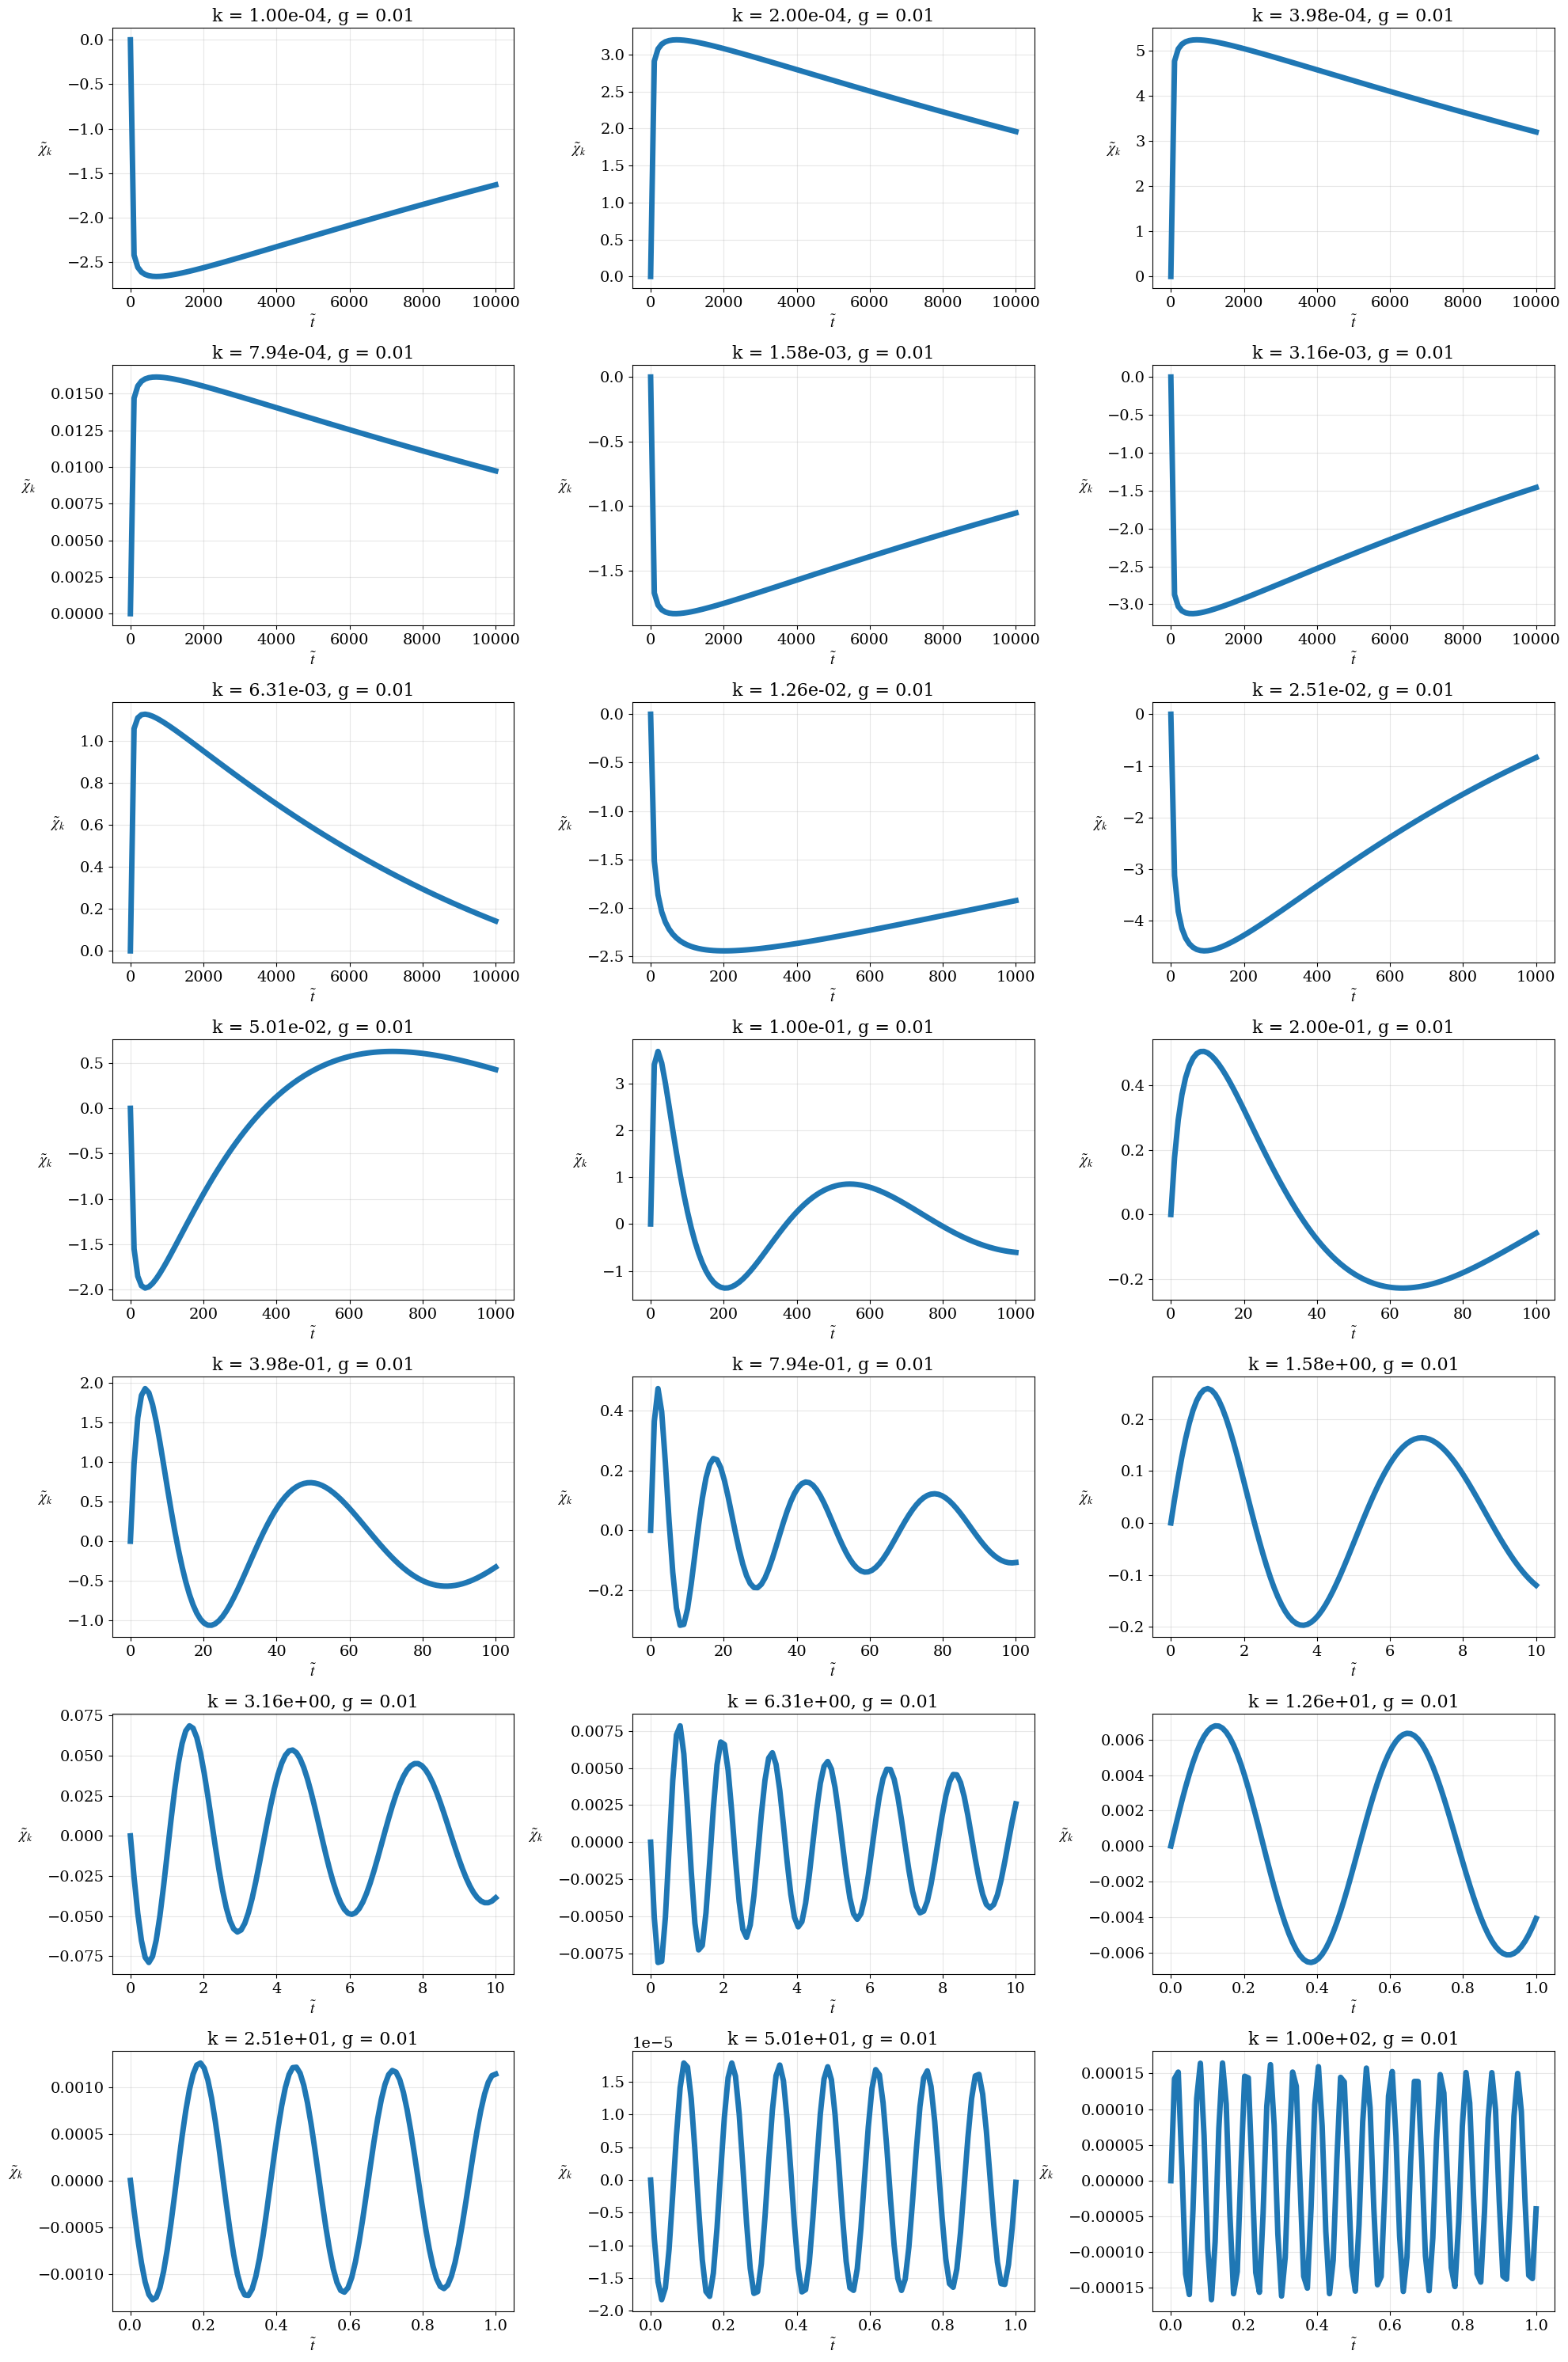

In [22]:
# Ahora veamos qué pasa para las amplitudes de chi de los modos para distintos valores de k

# Parámetros físicos
K = np.logspace(-4, 2, num=21)
g = 1e-2

# Rango de tiempo de integración
t0, tf = 0, [1e4,1e4,1e4,1e4,1e4,1e4,1e4,1e3,1e3,1e3,1e3,1e2,1e2,1e2,10,10,10,1,1,1,1]

# Condiciones iniciales
# Background
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2/np.sqrt(2)
areh = 1
areh_dot = areh * phi0**2/(np.sqrt(6))

plt.figure(figsize = (20, 30))
i = 0

for k in K:
    t_eval = np.linspace(t0, tf[i], int(1e2))

    # Perturbaciones
    Omega_phi = k**2+ 3 * phi0**2
    Omega_chi = k**2 + g**2 * phi0**2
    dphi_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))
    dphi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))
    chi_k0 = 0
    chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))

    y0 = [phi0, phi_dot0, dphi_k0, dphi_dot_k0, chi_k0, chi_dot_k0, areh, areh_dot]

    # Resolvamos el sistema acoplado
    sol = solve_ivp(pert, [t0, tf[i]], y0, args=(k, g), t_eval=t_eval, method = "RK45", rtol=1e-8, atol=1e-8)

    # Extraemos los resultados
    chi_sol = sol.y[4]
    i = i + 1

    plt.subplot(7,3,i)
    plt.plot(sol.t, chi_sol, lw = 5)
    plt.ylabel(r"$\tilde{\chi}_k$", labelpad = 20, rotation = "horizontal")
    plt.xlabel(r"$\tilde{t}$")
    plt.grid(alpha = 0.3)
    plt.title(f"k = {k:.2e}, g = {g}")

plt.tight_layout()
plt.show()

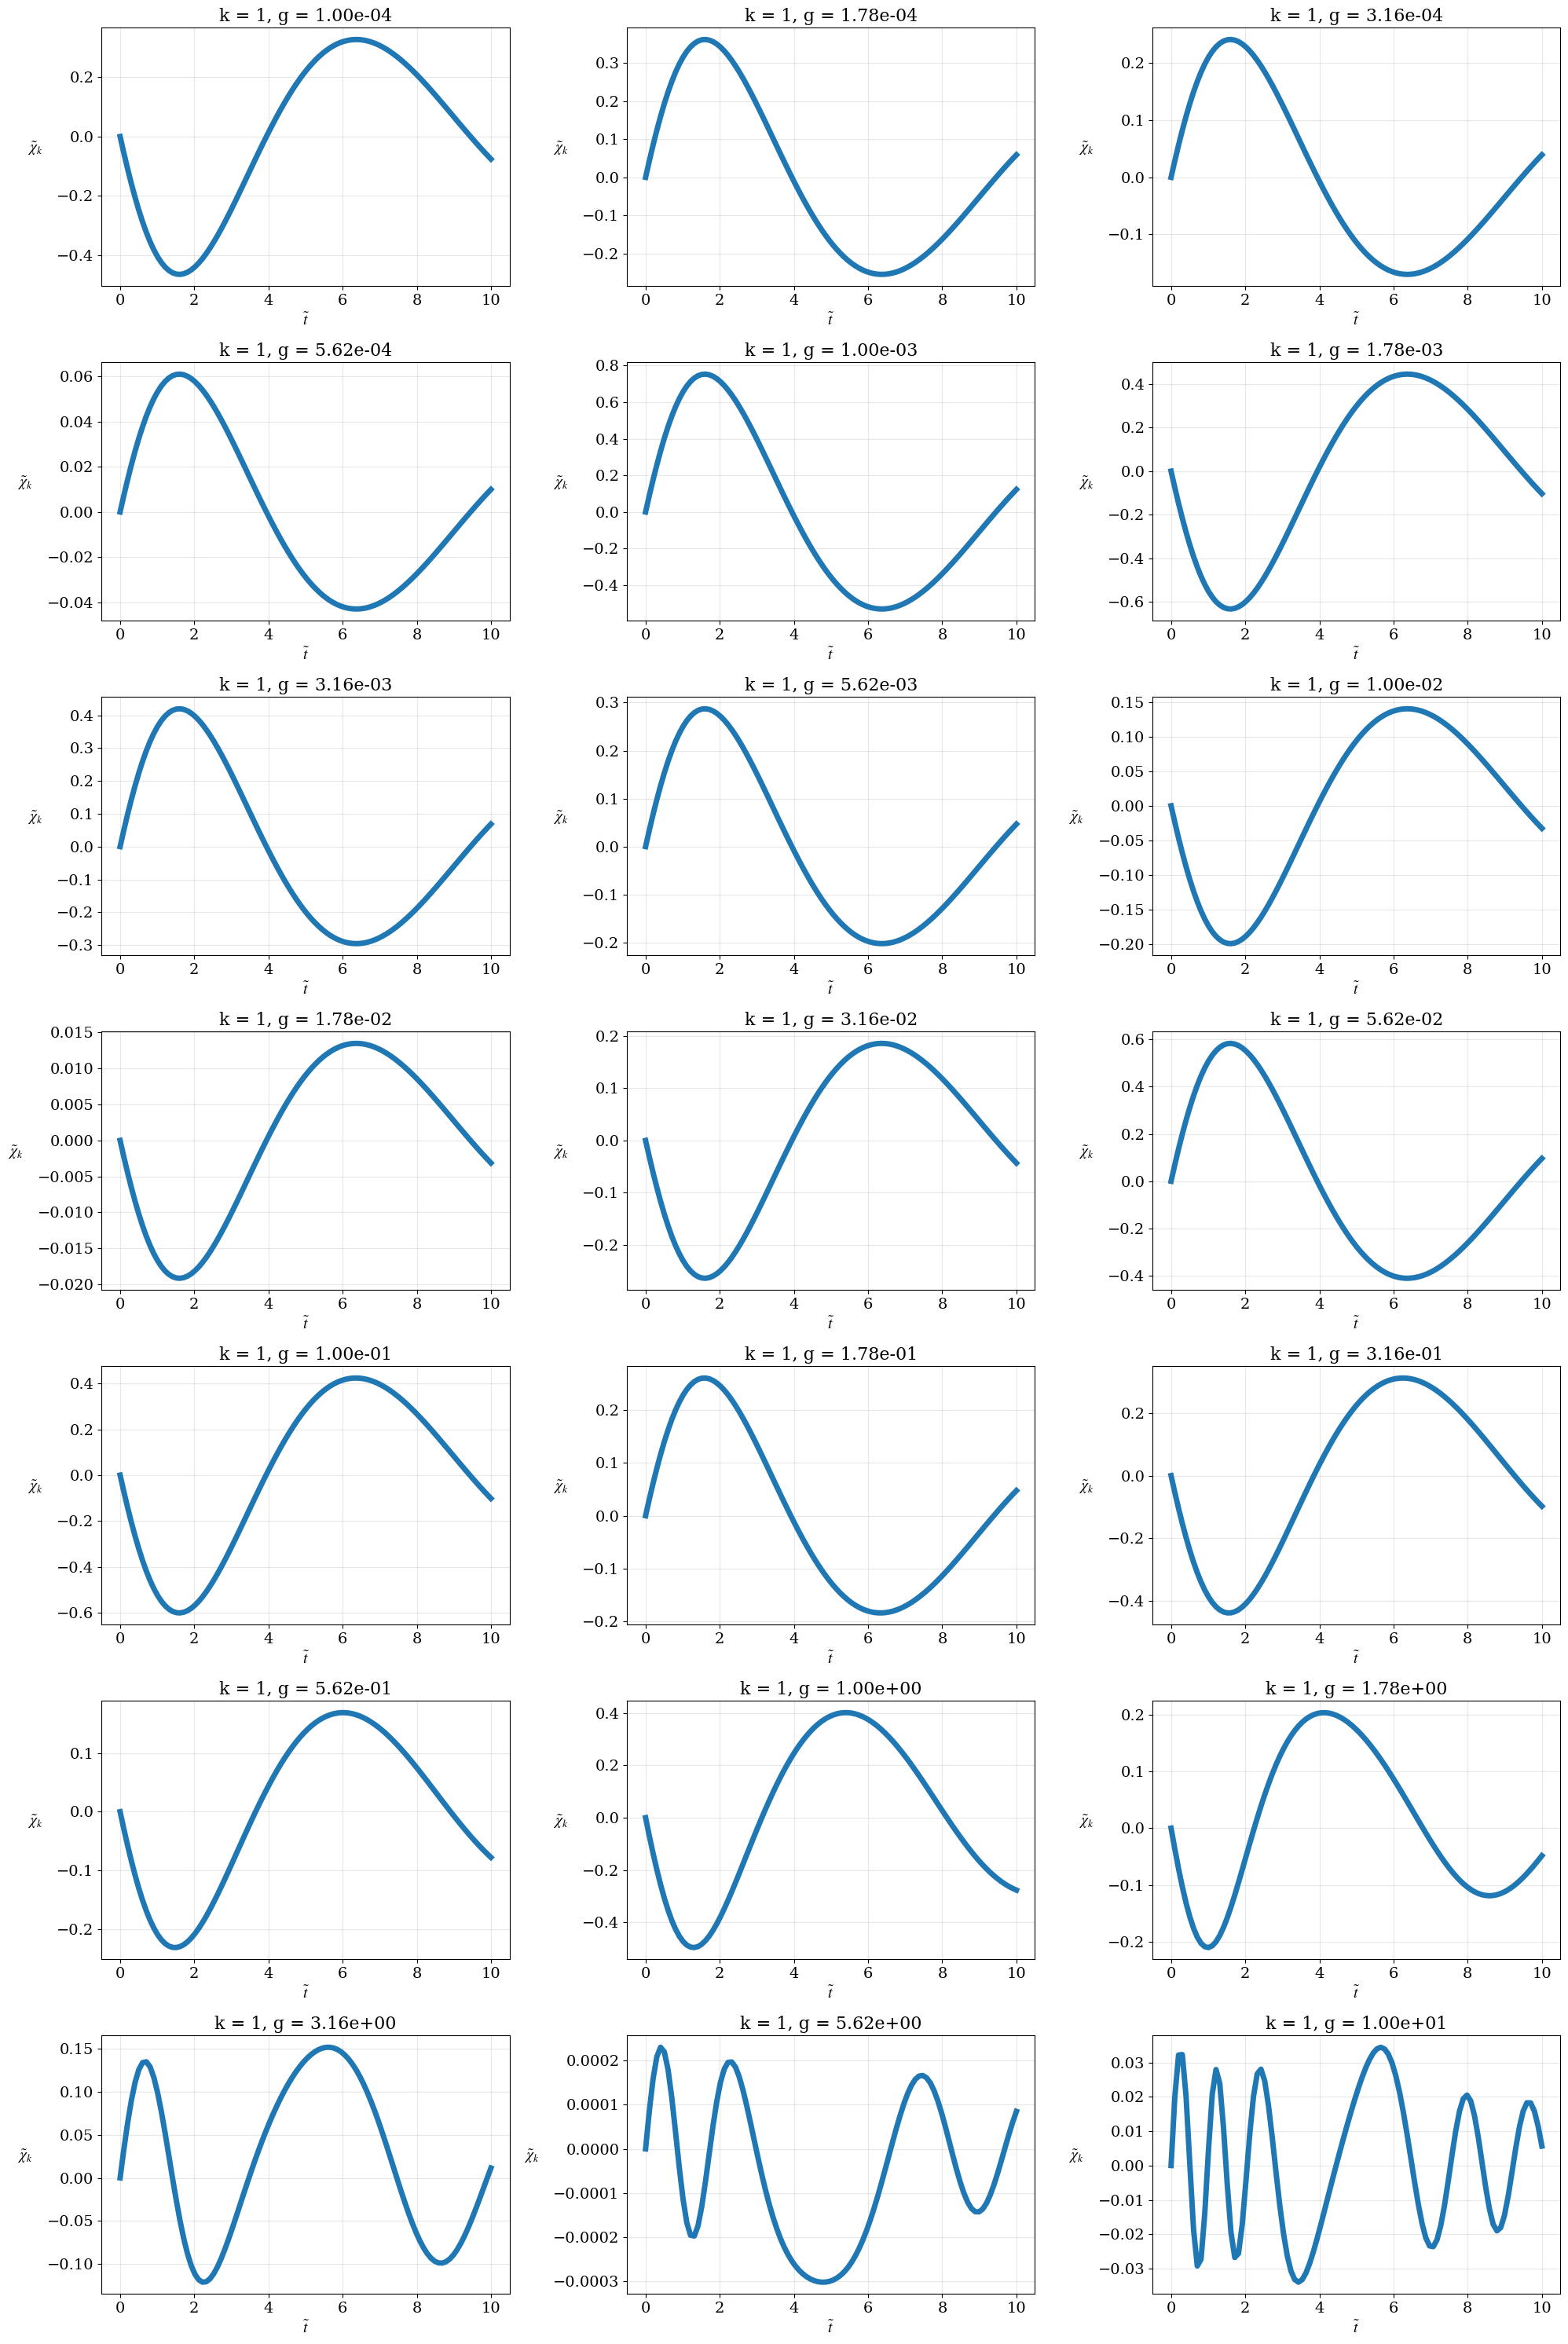

In [23]:
# Ahora veamos qué pasa para las amplitudes de chi de los modos para distintos valores de k

# Parámetros físicos
k = 1
G = np.logspace(-4,1,num=21)

# Rango de tiempo de integración
t0, tf = 0, 10
t_eval = np.linspace(t0, tf, int(1e2))


# Condiciones iniciales
# Background
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2/np.sqrt(2)
areh = 1
areh_dot = areh * phi0**2/(np.sqrt(6))

plt.figure(figsize = (20, 30))
i = 0

for g in G:
    # Perturbaciones
    Omega_phi = k**2+ 3 * phi0**2
    Omega_chi = k**2 + g**2 * phi0**2
    dphi_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))
    dphi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))
    chi_k0 = 0
    chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_phi)))

    y0 = [phi0, phi_dot0, dphi_k0, dphi_dot_k0, chi_k0, chi_dot_k0, areh, areh_dot]

    # Resolvamos el sistema acoplado
    sol = solve_ivp(pert, [t0, tf], y0, args=(k, g), t_eval=t_eval, method = "RK45", rtol=1e-8, atol=1e-8)

    # Extraemos los resultados
    chi_sol = sol.y[4]
    i = i + 1

    plt.subplot(7,3,i)
    plt.plot(sol.t, chi_sol, lw = 5)
    plt.ylabel(r"$\tilde{\chi}_k$", labelpad = 20, rotation = "horizontal")
    plt.xlabel(r"$\tilde{t}$")
    plt.grid(alpha = 0.3)
    plt.title(f"k = {k}, g = {g:.2e}")

plt.tight_layout()
plt.show()

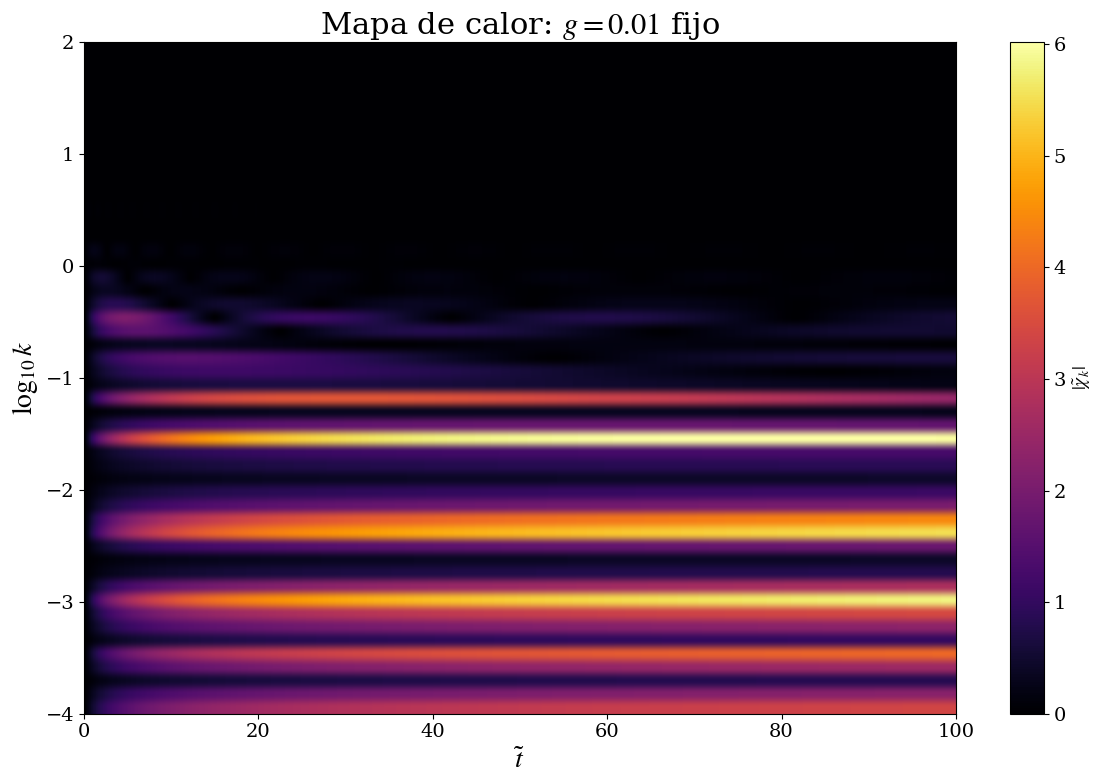

In [24]:
# Armemos tablas de instabilidad cómo las que armamos para la ecuación de Mathieu
# Parámetros
g = 1e-2  # g fijo
K = np.logspace(-4, 2, num=50)  # valores de k (eje y)
t0, tf = 0, 100
t_eval = np.linspace(t0, tf, 500)  # eje x (tiempo)

# Condiciones iniciales background
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2/np.sqrt(2)
areh = 1
areh_dot = areh * phi0**2/(np.sqrt(6))

# Prealoca matriz para amplitudes
chi_matrix = np.zeros((len(K), len(t_eval)))

for i, k in enumerate(K):
    Omega_phi = k**2 + 3 * phi0**2
    dphi_k0 = np.random.normal(loc=0, scale=1/(np.sqrt(2 * Omega_phi)))
    dphi_dot_k0 = np.random.normal(loc=0, scale=1/(np.sqrt(2 * Omega_phi)))
    chi_k0 = 0
    chi_dot_k0 = np.random.normal(loc=0, scale=1/(np.sqrt(2 * Omega_phi)))
    y0 = [phi0, phi_dot0, dphi_k0, dphi_dot_k0, chi_k0, chi_dot_k0, areh, areh_dot]
    sol = solve_ivp(pert, [t0, tf], y0, args=(k, g), t_eval=t_eval, method="RK45", rtol=1e-8, atol=1e-8)
    chi_matrix[i, :] = sol.y[4]  # amplitud de chi_k para cada t

# Graficar el mapa de calor
plt.figure(figsize=(12, 8))
extent = [t_eval[0], t_eval[-1], np.log10(K[0]), np.log10(K[-1])]
plt.imshow(np.abs(chi_matrix), aspect='auto', origin='lower', extent=extent, cmap='inferno')
plt.colorbar(label=r'$|\tilde{\chi}_k|$')
plt.xlabel(r'$\tilde{t}$', fontsize=20)
plt.ylabel(r'$\log_{10} k$', fontsize=20)
plt.title(f'Mapa de calor: $g={g}$ fijo', fontsize=22)
plt.tight_layout()
plt.show()

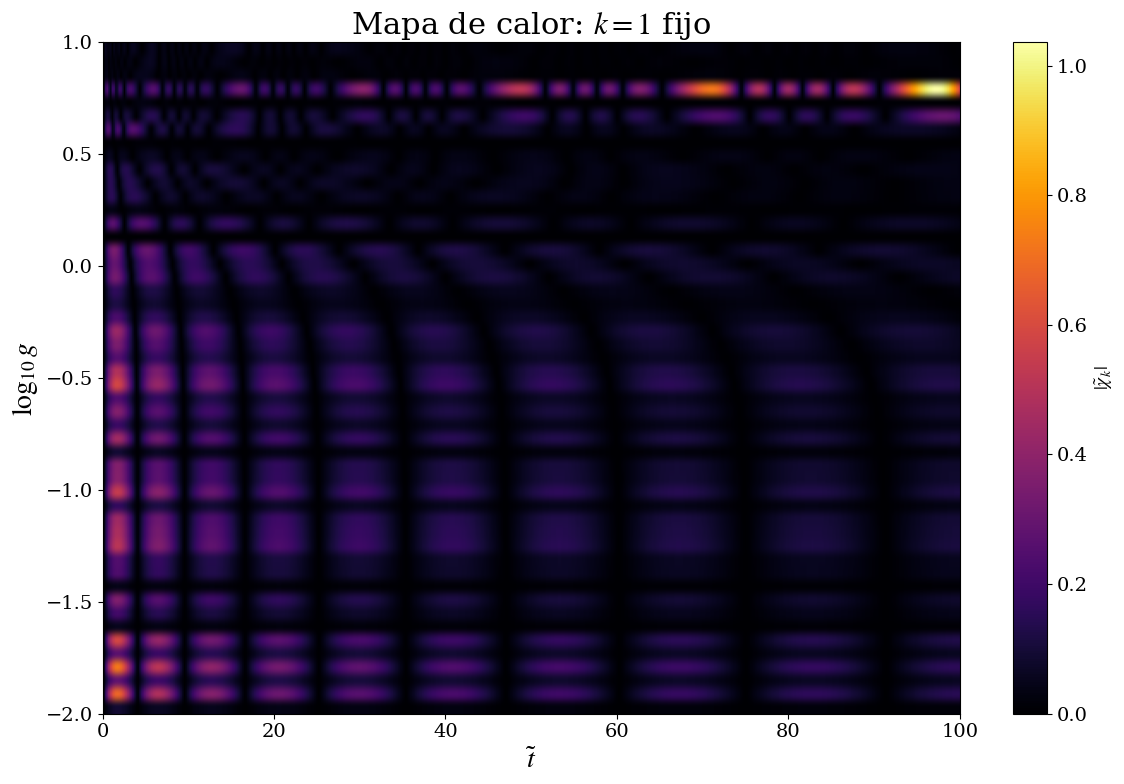

In [25]:
# Armemos tablas de instabilidad cómo las que armamos para la ecuación de Mathieu
# Parámetros
G = np.logspace(-2, 1, num=50)
k = 1  #Fijo
t0, tf = 0, 100
t_eval = np.linspace(t0, tf, 500)  # eje x (tiempo)

# Condiciones iniciales background
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2/np.sqrt(2)
areh = 1
areh_dot = areh * phi0**2/(np.sqrt(6))

# Prealoca matriz para amplitudes
chi_matrix = np.zeros((len(G), len(t_eval)))

for i, g in enumerate(G):
    Omega_phi = k**2 + 3 * phi0**2
    dphi_k0 = np.random.normal(loc=0, scale=1/(np.sqrt(2 * Omega_phi)))
    dphi_dot_k0 = np.random.normal(loc=0, scale=1/(np.sqrt(2 * Omega_phi)))
    chi_k0 = 0
    chi_dot_k0 = np.random.normal(loc=0, scale=1/(np.sqrt(2 * Omega_phi)))
    y0 = [phi0, phi_dot0, dphi_k0, dphi_dot_k0, chi_k0, chi_dot_k0, areh, areh_dot]
    sol = solve_ivp(pert, [t0, tf], y0, args=(k, g), t_eval=t_eval, method="RK45", rtol=1e-8, atol=1e-8)
    chi_matrix[i, :] = sol.y[4]  # amplitud de chi_k para cada t

# Graficar el mapa de calor
plt.figure(figsize=(12, 8))
extent = [t_eval[0], t_eval[-1], np.log10(G[0]), np.log10(G[-1])]
plt.imshow(np.abs(chi_matrix), aspect='auto', origin='lower', extent=extent, cmap='inferno')
plt.colorbar(label=r'$|\tilde{\chi}_k|$')
plt.xlabel(r'$\tilde{t}$', fontsize=20)
plt.ylabel(r'$\log_{10} g$', fontsize=20)
plt.title(f'Mapa de calor: $k={k}$ fijo', fontsize=22)
plt.tight_layout()
plt.show()

# Dinámica 2

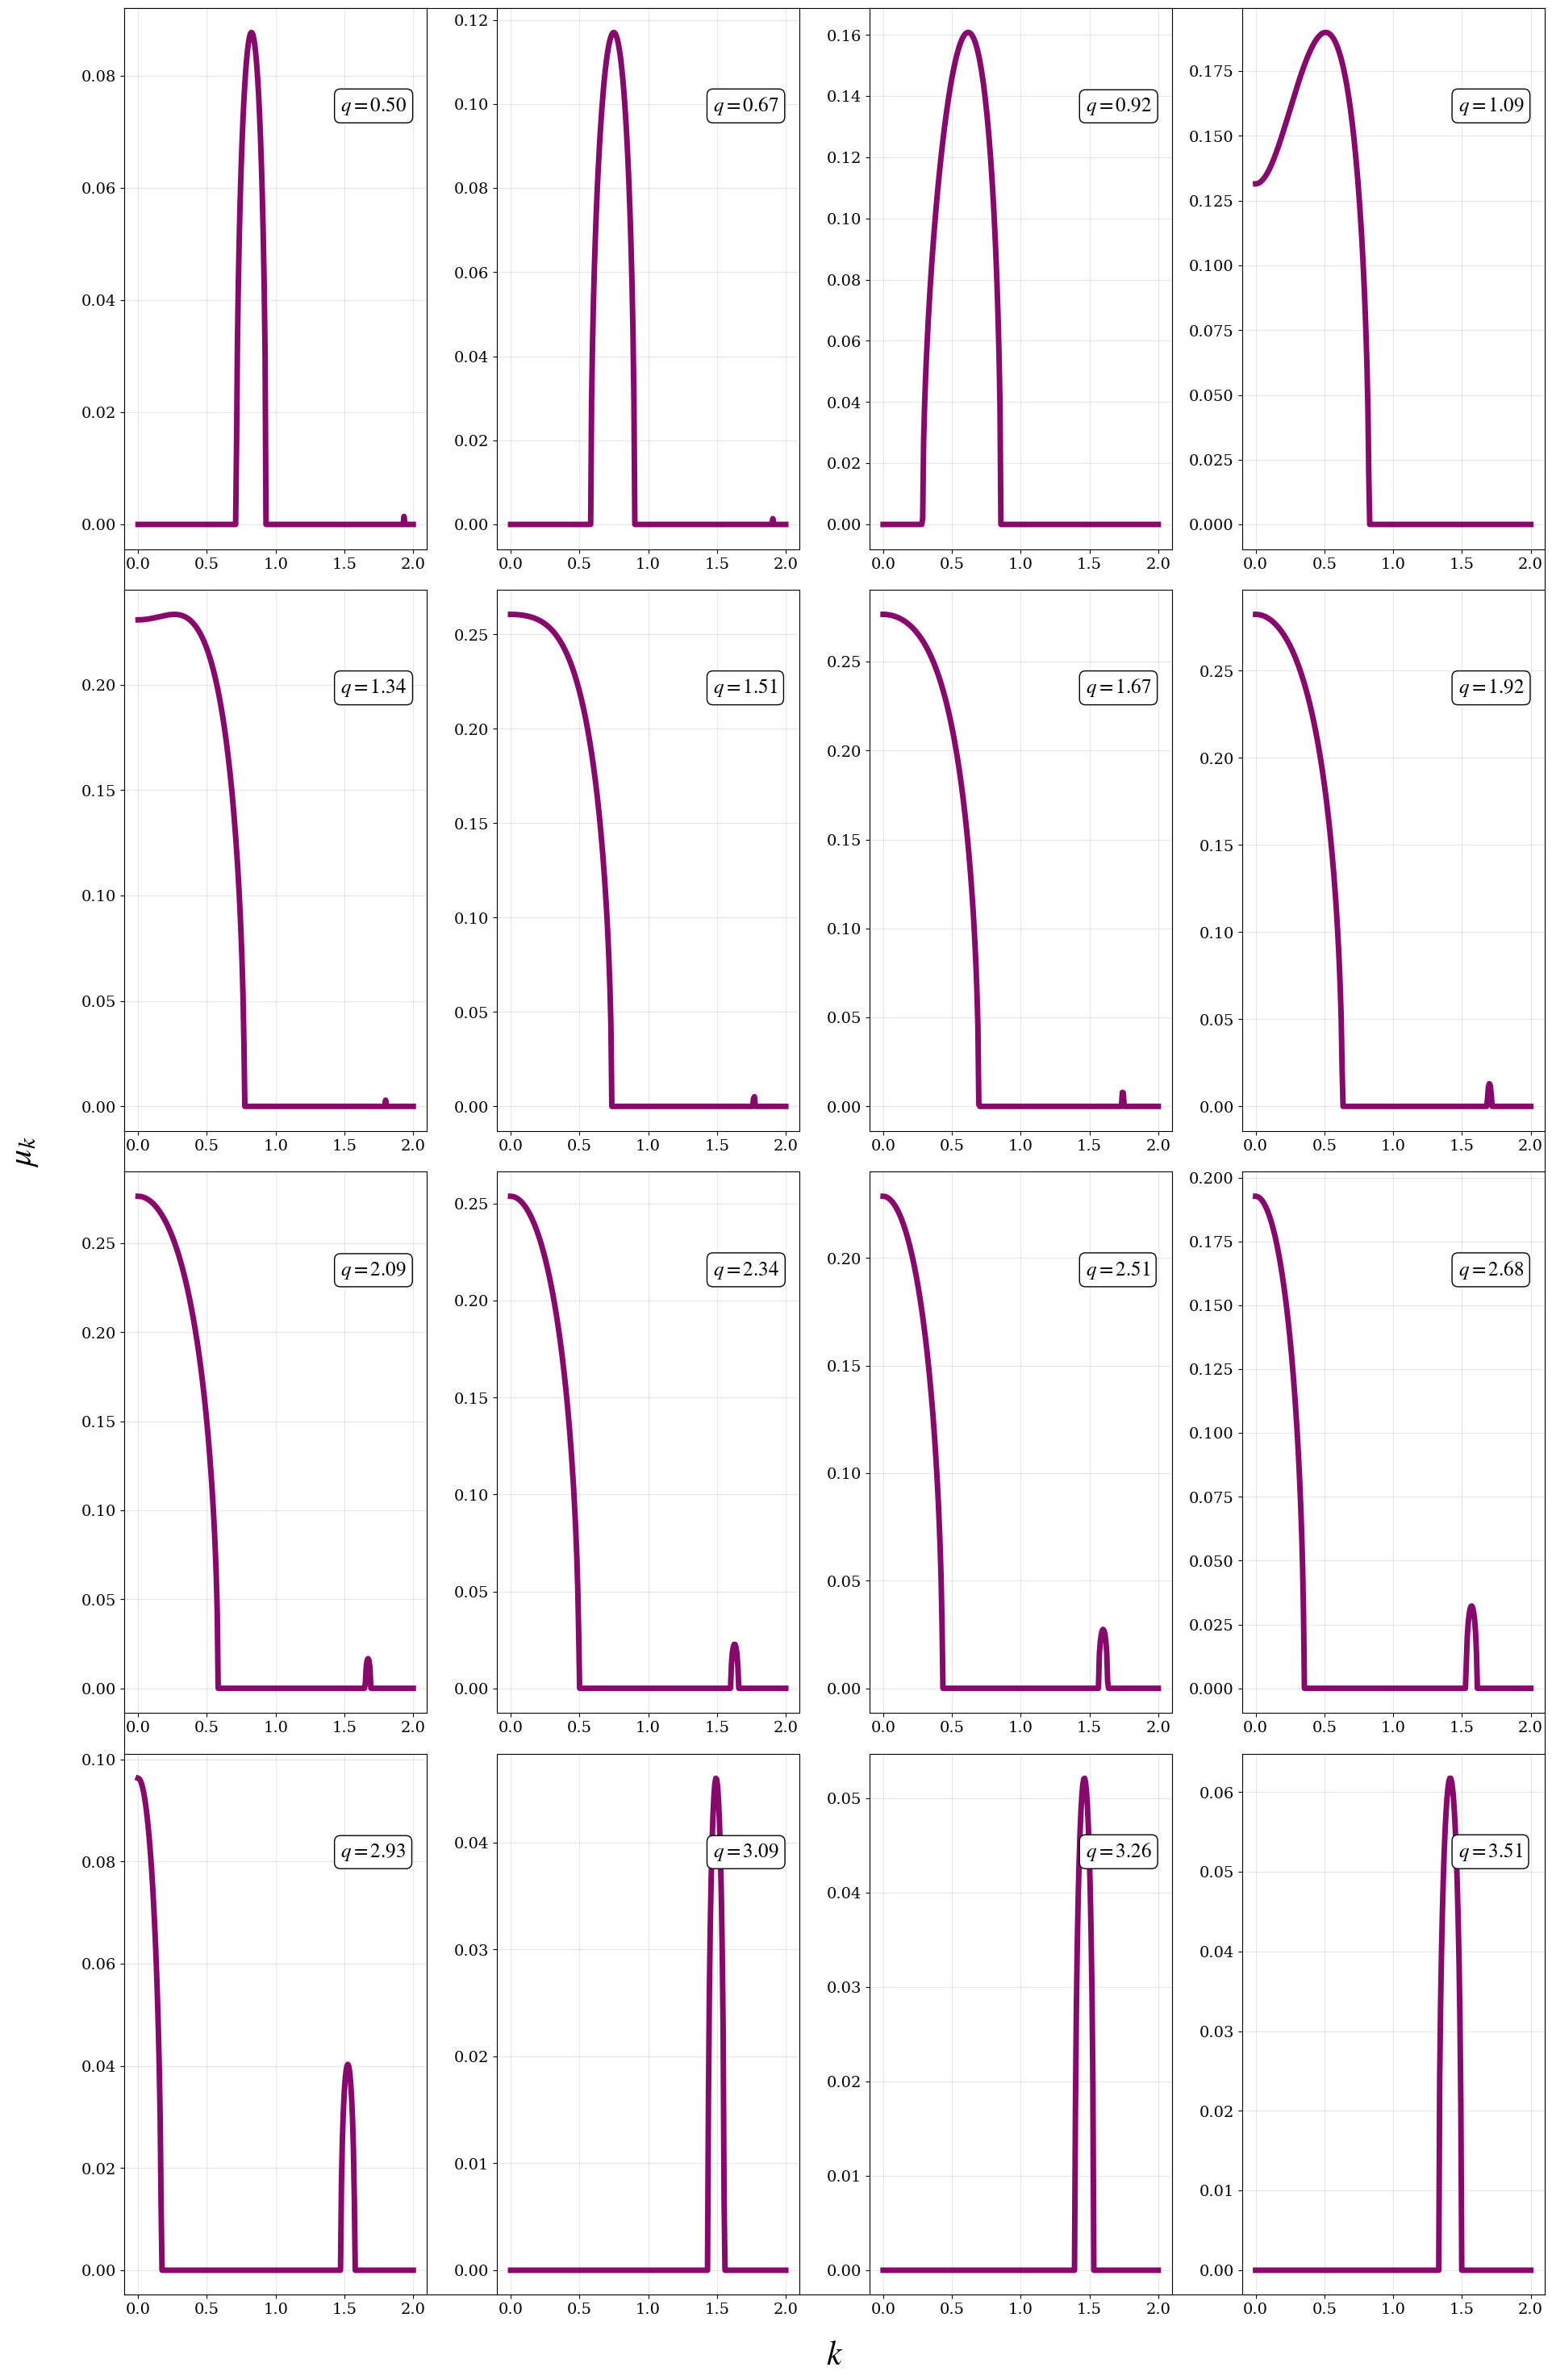

In [2]:
# Diagrama del coeficientente de Floquet en base a k para un g fijo
filename = "../Floquet/mathieu_lphi4(2).csv"

data = np.loadtxt(filename, delimiter=",")
qs = data[0, 1:]
ks = data[1:, 0]
mu = data[1:, 1:]

Q = np.linspace(0.5, 3.5, 16)
i = 0

plt.figure(figsize=(20, 30))
plt.xlabel(r'$k$', fontsize=30, labelpad=40)
plt.ylabel(r'$\mu_k$', fontsize=30, labelpad=75)
plt.xticks([])
plt.yticks([])

for q in Q:
    i += 1
    index = (np.abs(qs - q)).argmin()

    plt.subplot(4, 4, i)
    plt.plot(ks, np.real(mu[:, index]), label=f'$q={q}$', lw = 5, color = "#88086c")
    ymin, ymax = plt.gca().get_ylim()
    plt.text(x=ks[-80], y=ymax*0.8, s=rf'$q = {qs[index]:.2f}$', fontsize=18, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))
    plt.grid(alpha = 0.3)

plt.tight_layout()
plt.show()

In [2]:
# Función para las perturbaciones en el modelo λφ^4
def perturbation_lphi4(t, y, k, q):
    phi, phi_dot, chi_k, chi_dot_k = y
    phi_ddot = - phi**3
    chi_ddot_k = - (k**2 + q * phi**2) * chi_k
    return [phi_dot, phi_ddot, chi_dot_k, chi_ddot_k]

# Función para calcular el período de oscilación del inflatón
def oscilation_lphi4(E):
    def integrand(phi):
        V = 0.25 * phi**4
        return 1.0 / np.sqrt(2 * (E - V))
    phimax = (4*E)**(1/4)
    integral, _ = quad(integrand, 0, phimax)
    Tosc = 4*integral
    return Tosc

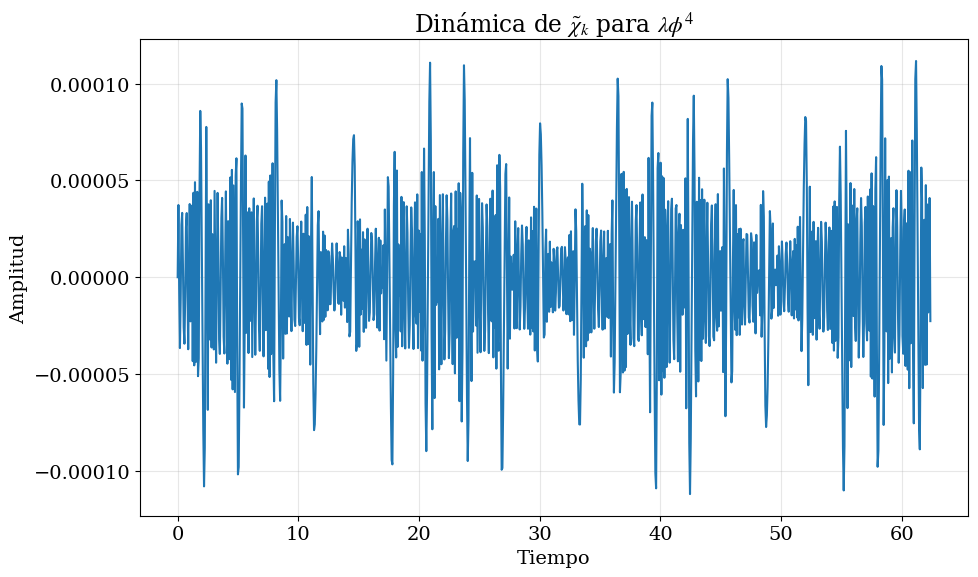

In [3]:
# Resolvamos la dinámica completa para un caso particular de broad resonance
q = 5050
k = np.sqrt(29)

# Condiciones iniciales
# Background
phi0 = 1
phi_dot0 = phi0**2/np.sqrt(2)
# Perturbaciones
Omega_chi = k**2 + q * phi0**2
chi_k0 = 0
chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_chi)))

y0 = [phi0, phi_dot0, chi_k0, chi_dot_k0]

Tosc = oscilation_lphi4(0.5 * phi_dot0**2 + 0.25 * phi0**4)
t_span = (0, 10 * Tosc)
sol = solve_ivp(perturbation_lphi4, t_span, y0, t_eval=np.linspace(0, 10 * Tosc, 1000), method='RK45', rtol=1e-6, args=(k, q))


plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[2], label=r'$\chi_k(t)$')
plt.xlabel('Tiempo')
plt.ylabel('Amplitud')
plt.title(r'Dinámica de $\tilde{\chi}_k$ para $\lambda \phi^4$')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

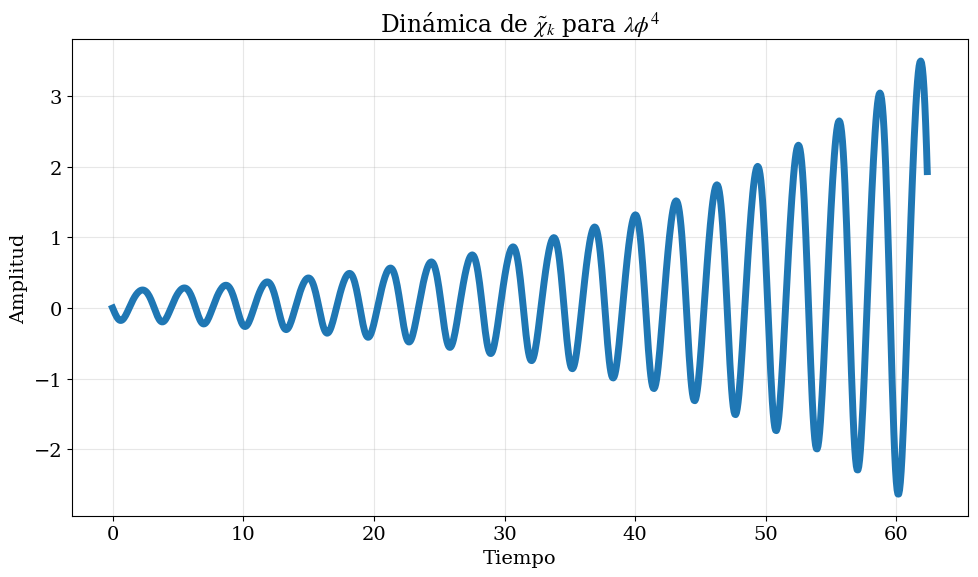

In [4]:
# Resolvamos la dinámica completa para un caso particular de narrow resonance
q = 3.09
k = 1.48

# Condiciones iniciales
# Background
phi0 = 1
phi_dot0 = phi0**2/np.sqrt(2)
# Perturbaciones
Omega_chi = k**2 + q * phi0**2
chi_k0 = 0
chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_chi)))

y0 = [phi0, phi_dot0, chi_k0, chi_dot_k0]

Tosc = oscilation_lphi4(0.5 * phi_dot0**2 + 0.25 * phi0**4)
t_span = (0, 10 * Tosc)
sol = solve_ivp(perturbation_lphi4, t_span, y0, t_eval=np.linspace(0, 10 * Tosc, 1000), method='RK45', rtol=1e-6, args=(k, q))


plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[2], label=r'$\chi_k(t)$', lw = 5)
plt.xlabel('Tiempo')
plt.ylabel('Amplitud')
plt.title(r'Dinámica de $\tilde{\chi}_k$ para $\lambda \phi^4$')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Número de partículas

El número de partículas del campo hijo estará dado por

$$n_\chi (k) = \frac{1}{2 \Omega_\chi} \left( \left| \frac{d \chi_k}{dT} \right|^2 + \Omega^2_\chi \left| \chi_k \right|^2 \right) - \frac{1}{2}$$

dónde

$$\Omega_\chi^2 (k, t) = \frac{k^2}{a^2} + g^2 \phi^2 (t)$$

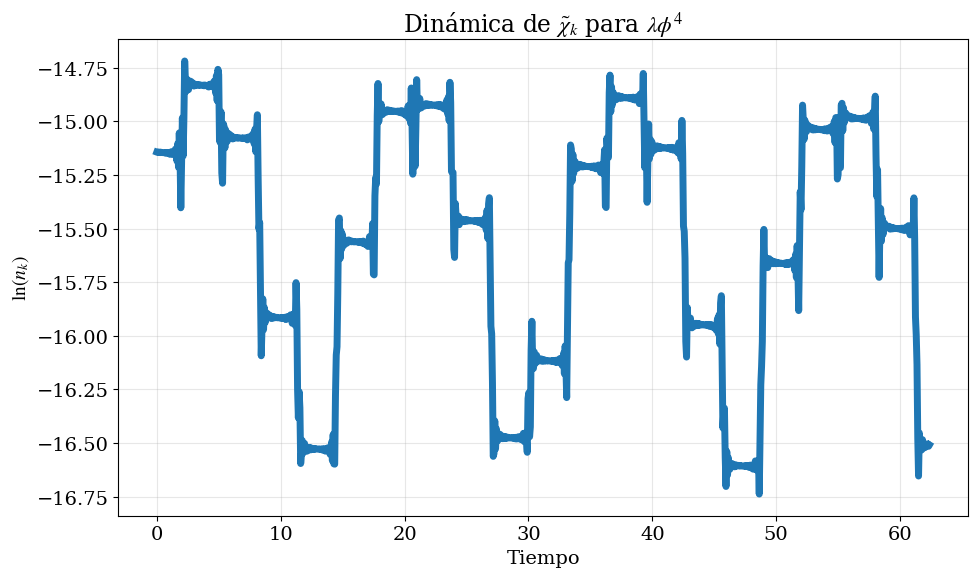

In [5]:
# Broad Resonance
q = 5050
k = np.sqrt(29)

# Condiciones iniciales
# Background
phi0 = 1
phi_dot0 = phi0**2/np.sqrt(2)
# Perturbaciones
Omega_chi = k**2 + q * phi0**2
chi_k0 = 0
chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_chi)))

y0 = [phi0, phi_dot0, chi_k0, chi_dot_k0]

Tosc = oscilation_lphi4(0.5 * phi_dot0**2 + 0.25 * phi0**4)
t_span = (0, 10 * Tosc)
sol = solve_ivp(perturbation_lphi4, t_span, y0, t_eval=np.linspace(0, 10 * Tosc, 1000), method='RK45', rtol=1e-6, args=(k, q))

omega_k = np.sqrt(k**2 + q * sol.y[0]**2)

nk = omega_k / 2 * ( np.abs(sol.y[3])**2 / omega_k**2 + np.abs(sol.y[2])**2 )

plt.figure(figsize=(10, 6))
plt.plot(sol.t, np.log(nk), lw = 5)
plt.xlabel('Tiempo')
plt.ylabel(r'$\ln(n_k)$')
plt.title(r'Dinámica de $\tilde{\chi}_k$ para $\lambda \phi^4$')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

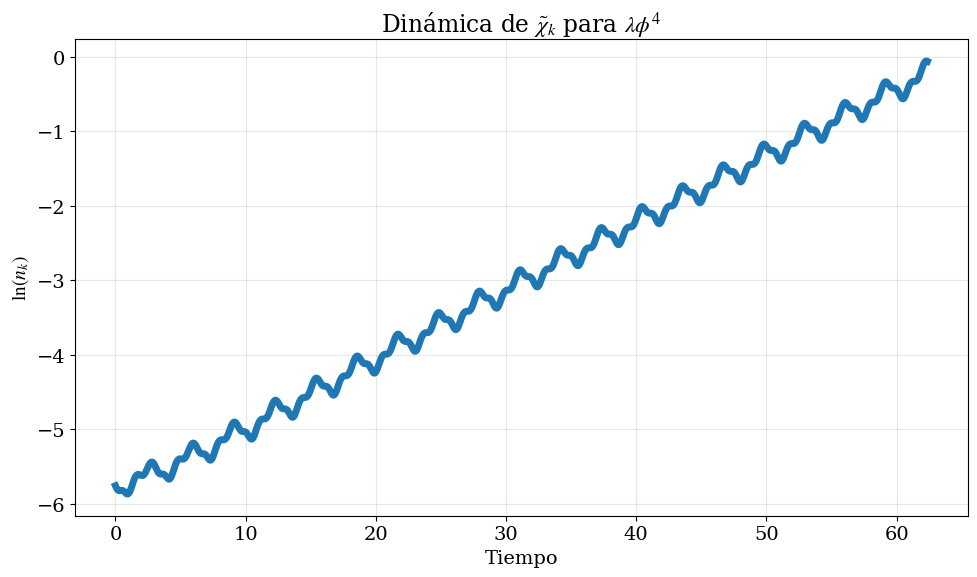

In [6]:
# Narrow Resonance
q = 3.09
k = 1.48

# Condiciones iniciales
# Background
phi0 = 1
phi_dot0 = phi0**2/np.sqrt(2)
# Perturbaciones
Omega_chi = k**2 + q * phi0**2
chi_k0 = 0
chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_chi)))

y0 = [phi0, phi_dot0, chi_k0, chi_dot_k0]

Tosc = oscilation_lphi4(0.5 * phi_dot0**2 + 0.25 * phi0**4)
t_span = (0, 10 * Tosc)
sol = solve_ivp(perturbation_lphi4, t_span, y0, t_eval=np.linspace(0, 10 * Tosc, 1000), method='RK45', rtol=1e-6, args=(k, q))

omega_k = np.sqrt(k**2 + q * sol.y[0]**2)

nk = omega_k / 2 * ( np.abs(sol.y[3])**2 / omega_k**2 + np.abs(sol.y[2])**2 )

plt.figure(figsize=(10, 6))
plt.plot(sol.t, np.log(nk), lw = 5)
plt.xlabel('Tiempo')
plt.ylabel(r'$\ln(n_k)$')
plt.title(r'Dinámica de $\tilde{\chi}_k$ para $\lambda \phi^4$')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Agregamos expansión

Para un modelo de preheating con $V(\phi) = \lambda \phi^4$ tenemos que las ecuaciones dinámicas adimensionales para el background son:

$$\begin{cases}
    \displaystyle \frac{d^2 \tilde{\phi}}{d \tilde{t}^2} + \frac{3}{a} \frac{d a}{d \tilde{t}} \frac{d \tilde{\phi}}{d \tilde{t}} + \tilde{\phi}^3 &= 0  \\ \\
    \displaystyle \frac{d^2 a}{d \tilde{t}^2} + \frac{a}{3} \left[ \left( \frac{d \tilde{\phi}}{d \tilde{t}} \right)^2 - \frac{\tilde{\phi}^4}{4} \right] &= 0
\end{cases}$$

Y para las perturbaciones, las ecuaciones adimensionales son:

$$\begin{cases}
    \displaystyle \frac{d^2 \delta \tilde{\phi}_k}{d \tilde{t}^2} + \frac{3}{a} \frac{d a}{d \tilde{t}} \frac{d \tilde{\phi}_k}{d \tilde{t}} + \left( \frac{\tilde{k}^2}{a^2} + 3 \tilde{\phi}^2 \right) \delta \tilde{\phi}_k &= 0\\
    \displaystyle \frac{d^2 \tilde{\chi}_k}{d \tilde{t}^2} + \frac{3}{a} \frac{d a}{d \tilde{t}} \frac{d \tilde{\chi}_k}{d \tilde{t}} + \left( \frac{\tilde{k}^2}{a^2} + g^2 \tilde{\phi}^2 \right) \tilde{\chi}_k &= 0
\end{cases}$$

In [7]:
def pert_exp(t, y, k, q):
    phi, phi_dot, chi_k, chi_dot_k, a, a_dot = y

    # Evolución de a(t)
    a_ddot = - a/3 * (phi_dot**2 - phi**4/4)
    H = a_dot/a
    
    # Ecuación para φ
    phi_ddot = -3 * H * phi_dot - phi **3
    
    # Ecuaciones para χ_k
    chi_ddot_k = - 3 * H * chi_dot_k - (k ** 2 / a**2 + q * phi**2) * chi_k 
    
    return [phi_dot, phi_ddot, chi_dot_k, chi_ddot_k, a_dot, a_ddot]

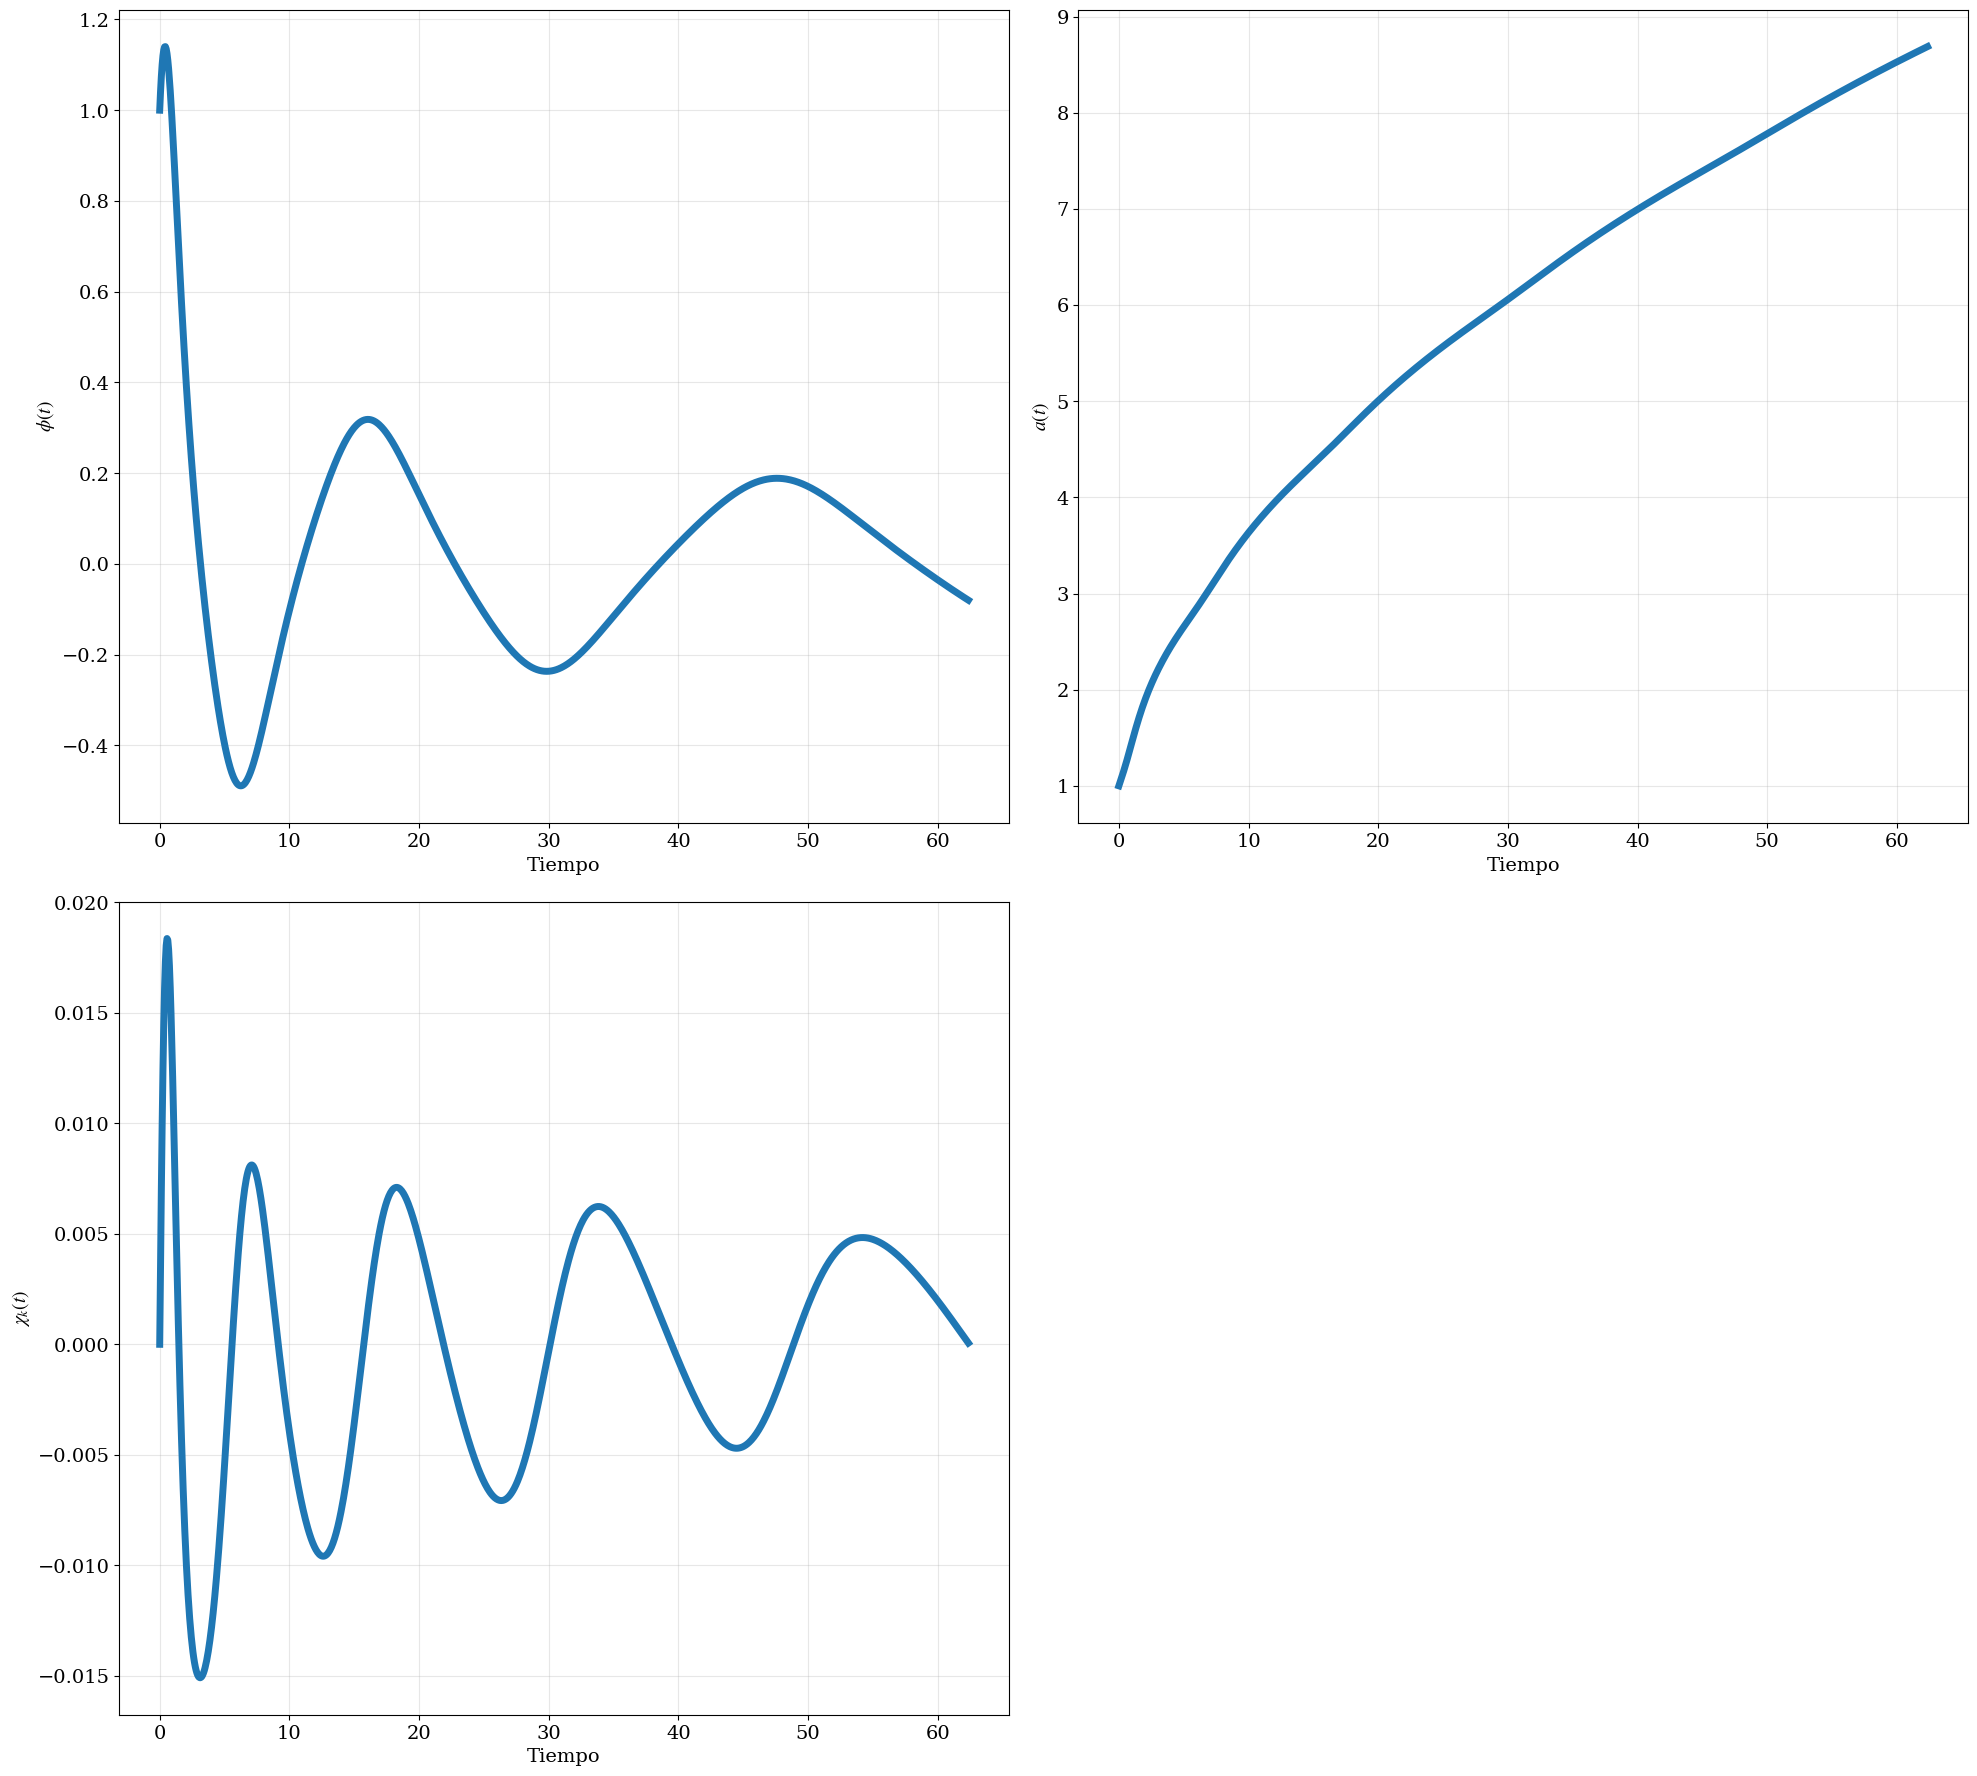

In [8]:
# Resolvamos la dinámica completa para un caso particular de narrow resonance
q = 3.09
k = 1.48

# Condiciones iniciales

# Background
phi0 = 1
phi_dot0 = phi0**2/np.sqrt(2)
areh = 1
areh_dot = areh * phi0**2/(np.sqrt(6))

# Perturbaciones
Omega_chi = k**2/areh**2 + q * phi0**2
chi_k0 = 0
chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_chi)))

y0 = [phi0, phi_dot0, chi_k0, chi_dot_k0, areh, areh_dot]

Tosc = oscilation_lphi4(0.5 * phi_dot0**2 + 0.25 * phi0**4)
t_span = (0, 10 * Tosc)
sol = solve_ivp(pert_exp, t_span, y0, t_eval=np.linspace(0, 10 * Tosc, 1000), method='RK45', rtol=1e-6, args=(k, q))


plt.figure(figsize=(20, 18))

plt.subplot(2,2,1)
plt.plot(sol.t, sol.y[0], label=r'$a(t)$', lw = 5)
plt.xlabel('Tiempo')
plt.ylabel(r'$\phi(t)$')
plt.grid(alpha=0.3)

plt.subplot(2,2,2)
plt.plot(sol.t, sol.y[4], label=r'$a(t)$', lw = 5)
plt.xlabel('Tiempo')
plt.ylabel(r'$a(t)$')
plt.grid(alpha=0.3)

plt.subplot(2,2,3)
plt.plot(sol.t, sol.y[2], label=r'$\chi_k(t)$', lw = 5)
plt.xlabel('Tiempo')
plt.ylabel(r'$\chi_k (t)$')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

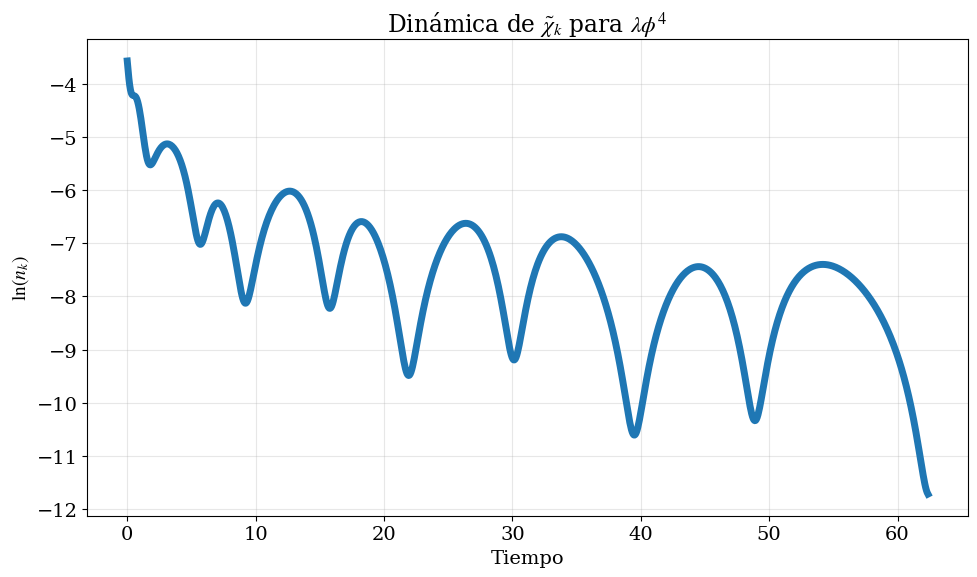

In [9]:
# Veamos el número de partículas
q = 3.09
k = 1.48

# Condiciones iniciales

# Background
phi0 = 1
phi_dot0 = phi0**2/np.sqrt(2)
areh = 1
areh_dot = areh * phi0**2/(np.sqrt(6))

# Perturbaciones
Omega_chi = k**2/areh**2 + q * phi0**2
chi_k0 = 0
chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_chi)))

y0 = [phi0, phi_dot0, chi_k0, chi_dot_k0, areh, areh_dot]

Tosc = oscilation_lphi4(0.5 * phi_dot0**2 + 0.25 * phi0**4)
t_span = (0, 10 * Tosc)
sol = solve_ivp(pert_exp, t_span, y0, t_eval=np.linspace(0, 10 * Tosc, 1000), method='RK45', rtol=1e-6, args=(k, q))
omega_k = np.sqrt(k**2 + q * sol.y[0]**2)

nk = omega_k / 2 * ( np.abs(sol.y[3])**2 / omega_k**2 + np.abs(sol.y[2])**2 )

plt.figure(figsize=(10, 6))
plt.plot(sol.t, np.log(nk), lw = 5)
plt.xlabel('Tiempo')
plt.ylabel(r'$\ln(n_k)$')
plt.title(r'Dinámica de $\tilde{\chi}_k$ para $\lambda \phi^4$')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

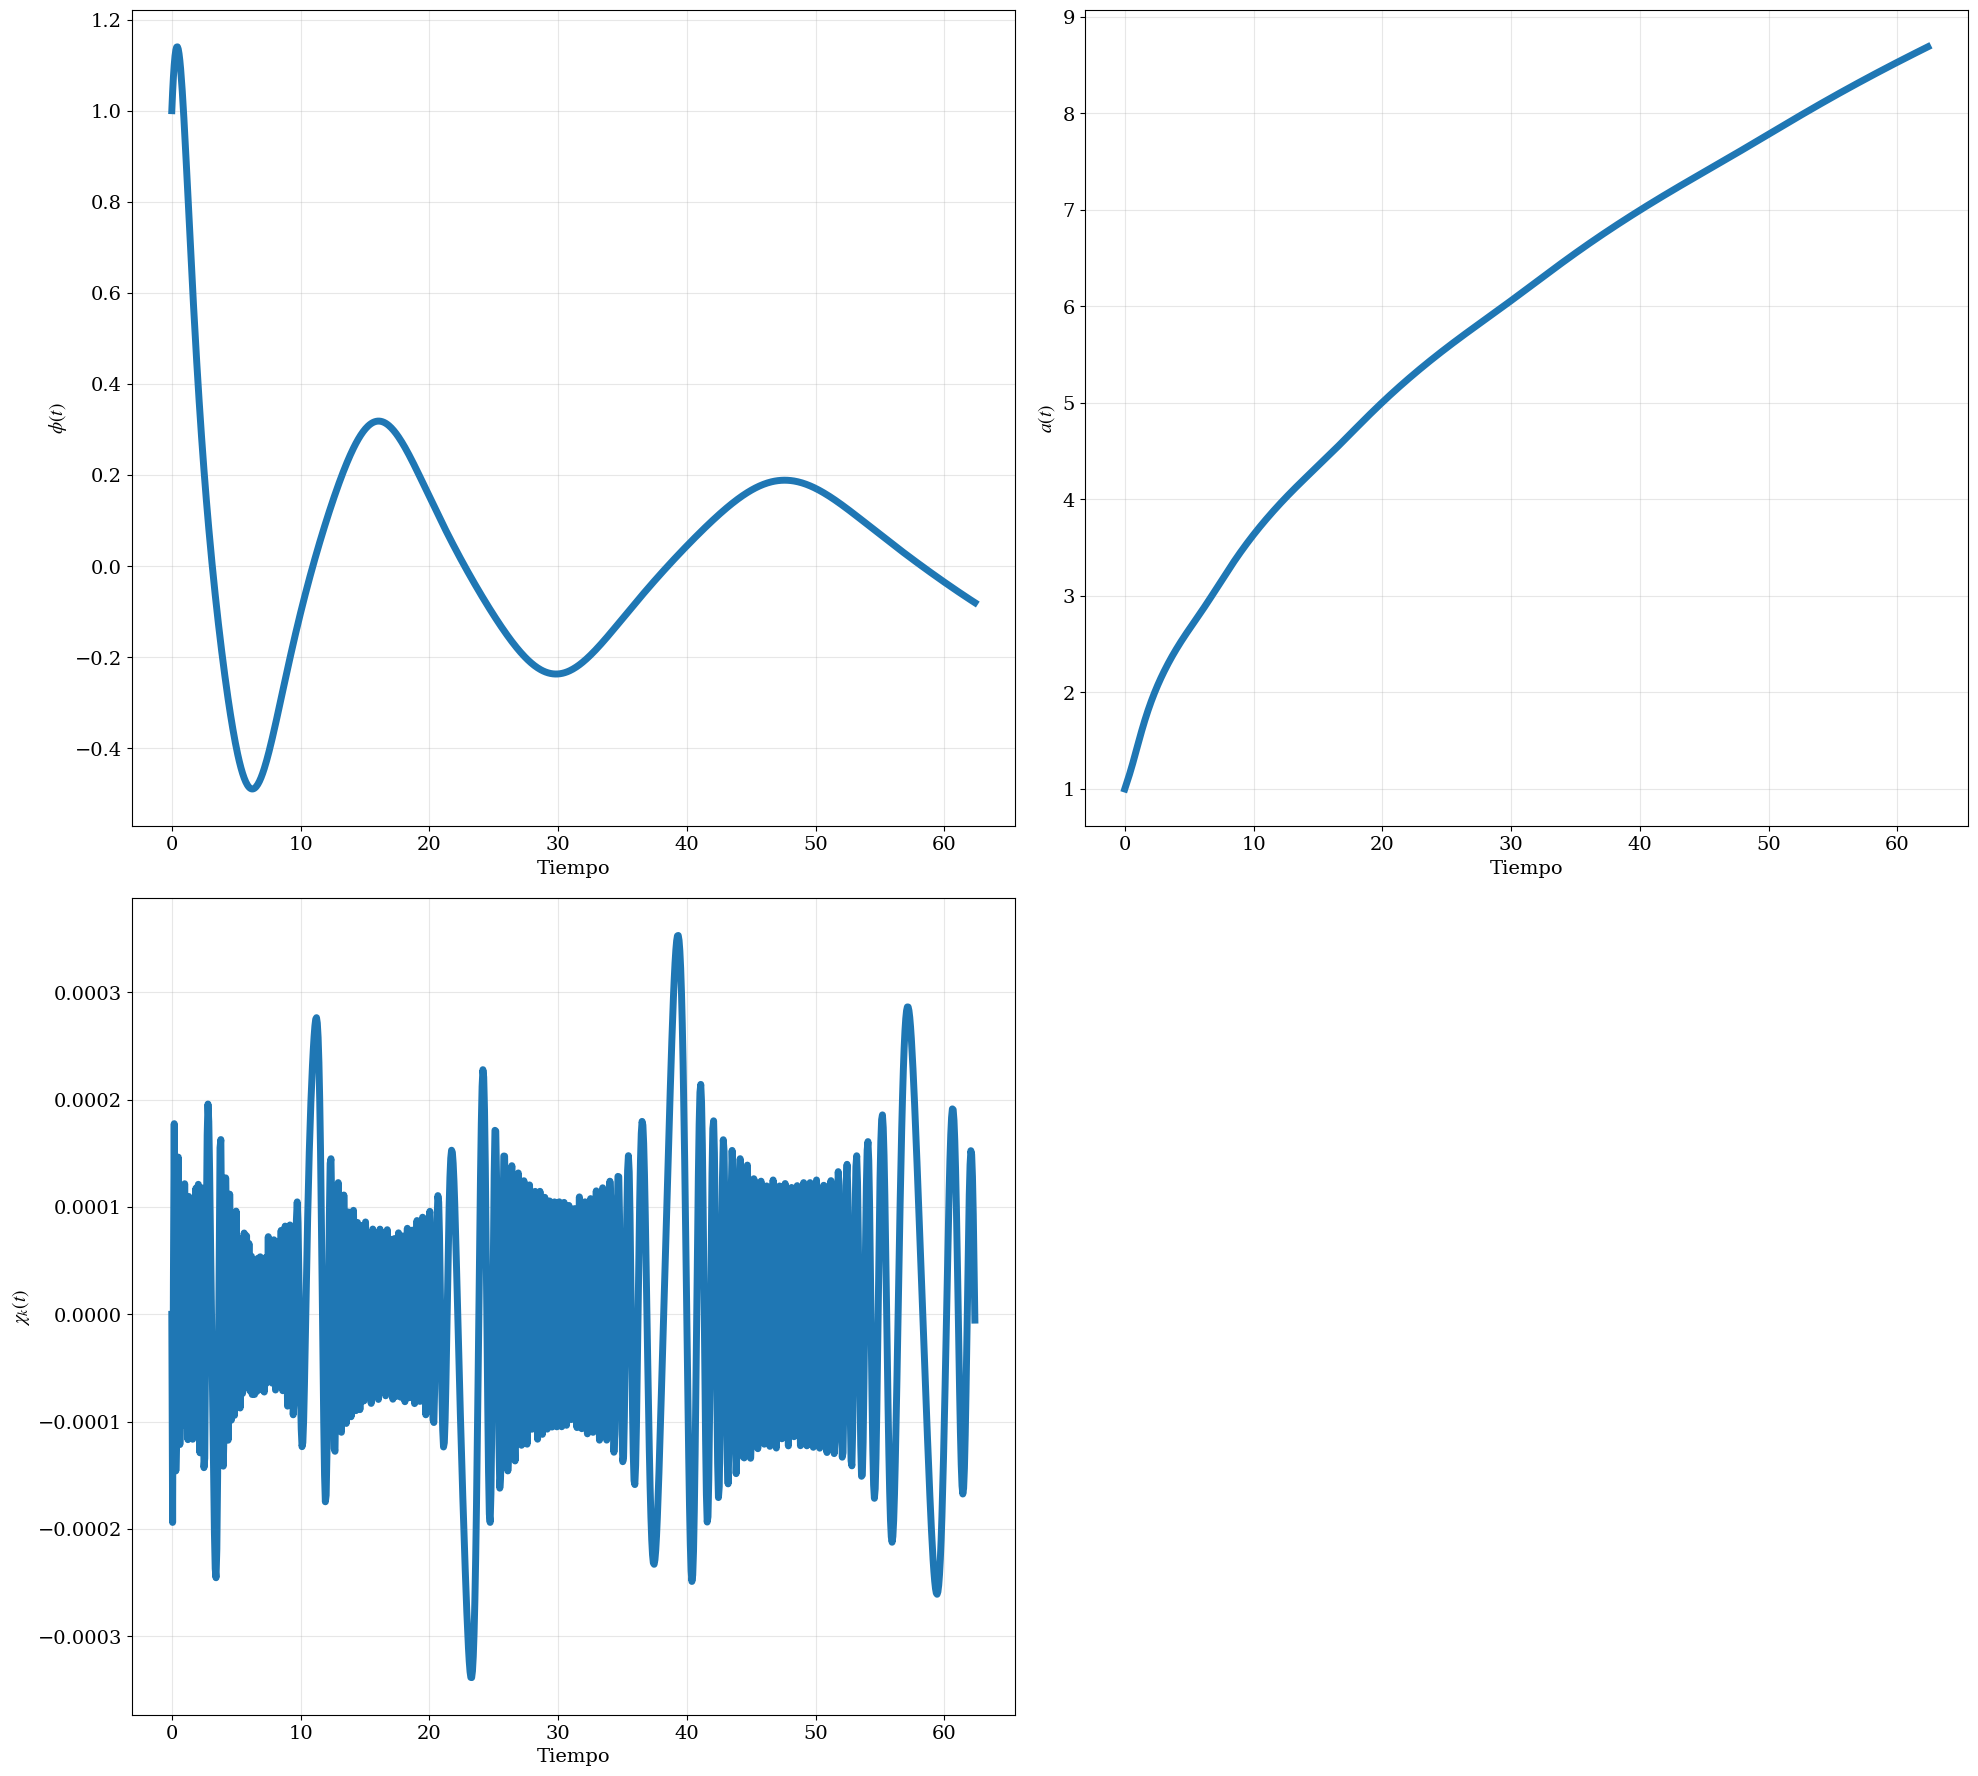

In [10]:
# Resolvamos la dinámica completa para un caso particular de broad resonance
q = 5050
k = np.sqrt(29)

# Condiciones iniciales

# Background
phi0 = 1
phi_dot0 = phi0**2/np.sqrt(2)
areh = 1
areh_dot = areh * phi0**2/(np.sqrt(6))

# Perturbaciones
Omega_chi = k**2/areh**2 + q * phi0**2
chi_k0 = 0
chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_chi)))

y0 = [phi0, phi_dot0, chi_k0, chi_dot_k0, areh, areh_dot]

Tosc = oscilation_lphi4(0.5 * phi_dot0**2 + 0.25 * phi0**4)
t_span = (0, 10 * Tosc)
sol = solve_ivp(pert_exp, t_span, y0, t_eval=np.linspace(0, 10 * Tosc, 1000), method='RK45', rtol=1e-6, args=(k, q))


plt.figure(figsize=(20, 18))

plt.subplot(2,2,1)
plt.plot(sol.t, sol.y[0], label=r'$a(t)$', lw = 5)
plt.xlabel('Tiempo')
plt.ylabel(r'$\phi(t)$')
plt.grid(alpha=0.3)

plt.subplot(2,2,2)
plt.plot(sol.t, sol.y[4], label=r'$a(t)$', lw = 5)
plt.xlabel('Tiempo')
plt.ylabel(r'$a(t)$')
plt.grid(alpha=0.3)

plt.subplot(2,2,3)
plt.plot(sol.t, sol.y[2], label=r'$\chi_k(t)$', lw = 5)
plt.xlabel('Tiempo')
plt.ylabel(r'$\chi_k (t)$')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

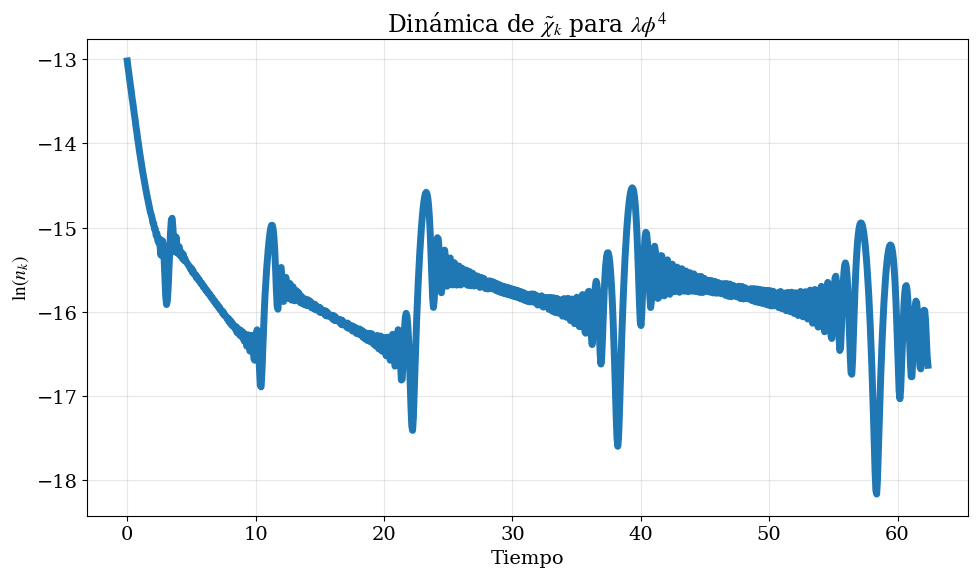

In [11]:
# Veamos el número de partículas
q = 5050
k = np.sqrt(29)

# Condiciones iniciales

# Background
phi0 = 1
phi_dot0 = phi0**2/np.sqrt(2)
areh = 1
areh_dot = areh * phi0**2/(np.sqrt(6))

# Perturbaciones
Omega_chi = k**2/areh**2 + q * phi0**2
chi_k0 = 0
chi_dot_k0 = np.random.normal(loc = 0, scale = 1/(np.sqrt(2 * Omega_chi)))

y0 = [phi0, phi_dot0, chi_k0, chi_dot_k0, areh, areh_dot]

Tosc = oscilation_lphi4(0.5 * phi_dot0**2 + 0.25 * phi0**4)
t_span = (0, 10 * Tosc)
sol = solve_ivp(pert_exp, t_span, y0, t_eval=np.linspace(0, 10 * Tosc, 1000), method='RK45', rtol=1e-6, args=(k, q))
omega_k = np.sqrt(k**2 + q * sol.y[0]**2)

nk = omega_k / 2 * ( np.abs(sol.y[3])**2 / omega_k**2 + np.abs(sol.y[2])**2 )

plt.figure(figsize=(10, 6))
plt.plot(sol.t, np.log(nk), lw = 5)
plt.xlabel('Tiempo')
plt.ylabel(r'$\ln(n_k)$')
plt.title(r'Dinámica de $\tilde{\chi}_k$ para $\lambda \phi^4$')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Espectro de potencias

In [6]:
def pert_exp(t, y, k, g):
    phi, phi_dot, chi_k, chi_dot_k, a, a_dot = y
    a_ddot = - a/3 * (phi_dot**2 - phi**4/4)
    H = a_dot/a
    phi_ddot = -3 * H * phi_dot - phi**3
    chi_ddot_k = - 3 * H * chi_dot_k - (k**2 / a**2 + g**2 * phi**2) * chi_k 
    return [phi_dot, phi_ddot, chi_dot_k, chi_ddot_k, a_dot, a_ddot]

def perturbation_lphi4(t, y, k, q):
    phi, phi_dot, chi_k, chi_dot_k = y
    phi_ddot = - phi**3
    chi_ddot_k = - (k**2 + q * phi**2) * chi_k
    return [phi_dot, phi_ddot, chi_dot_k, chi_ddot_k]

def Pchi(chi_k, k):
    return (k**3 / (2 * np.pi**2)) * (np.abs(chi_k)**2)

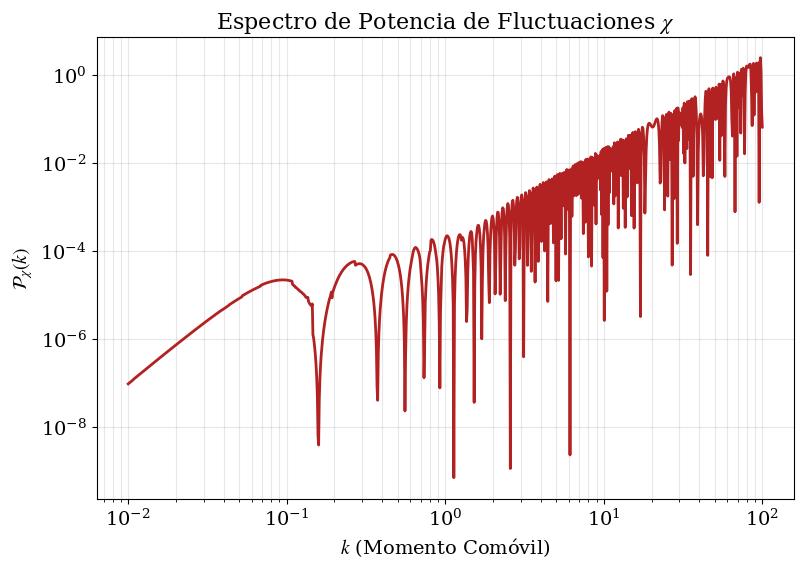

In [ ]:
# Parámetros
g = 0.1
n_k = 1000
ks = np.logspace(-2, 2, n_k)
t_span = (0, 100)
chi_values = np.zeros(n_k)

for i, k in enumerate(ks):
    # Condiciones iniciales
    phi0 = 1.0
    phi_dot0 = phi0**2/np.sqrt(2)
    areh = 1.0
    areh_dot = np.sqrt((1/3) * (0.5 * phi_dot0**2 + 0.25 * phi0**4))
    
    # Perturbaciones
    Omega_chi = np.sqrt(k**2/areh**2 + g**2 * phi0**2)
    chi_k0 = 1.0 / np.sqrt(2 * Omega_chi)
    chi_dot_k0 = 0.0
    
    y0 = [phi0, phi_dot0, chi_k0, chi_dot_k0, areh, areh_dot] 

    sol_k = solve_ivp(pert_exp, t_span, y0, args=(k, g), method='RK45')
    
    chi_values[i] = sol_k.y[2, -1]

# Calculo P_chi para cada k usando los valores finales guardados
P_chi_vals = [Pchi(chi_val, k_val) for chi_val, k_val in zip(chi_values, ks)]

# Grafico
plt.figure(figsize=(9, 6))
plt.plot(ks, P_chi_vals, lw=2, color='firebrick')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k$ (Momento Comóvil)', fontsize=14)
plt.ylabel(r'$\mathcal{P}_{\chi}(k)$', fontsize=14)
plt.title(r'Espectro de Potencia de Fluctuaciones $\chi$', fontsize=16)
plt.grid(True, which="both", alpha=0.3)
plt.show()

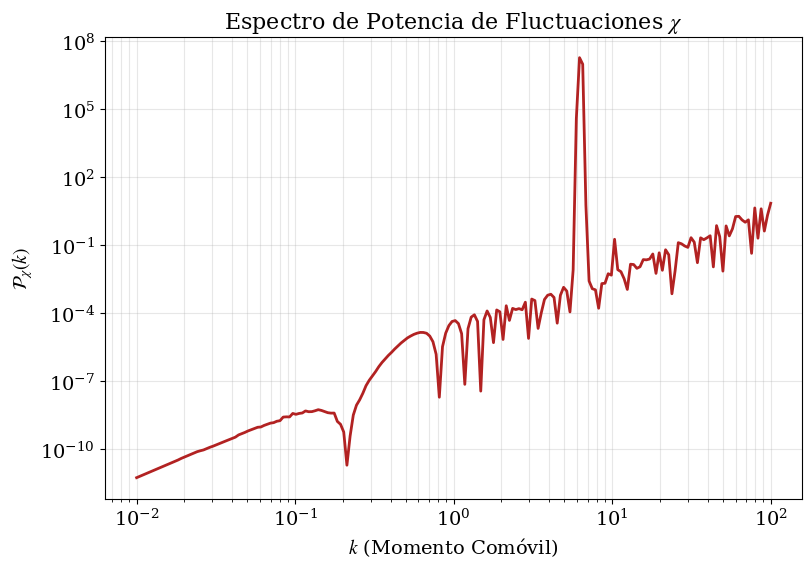

In [12]:
# Parámetros
g = 5050
n_k = 200
ks = np.logspace(-2, 2, n_k)
t_span = (0, 100)
chi_values = np.zeros(n_k)

for i, k in enumerate(ks):
    # Condiciones iniciales
    phi0 = 1.0
    phi_dot0 = phi0**2/np.sqrt(2)
    areh = 1.0
    areh_dot = np.sqrt((1/3) * (0.5 * phi_dot0**2 + 0.25 * phi0**4))
    
    # Perturbaciones
    Omega_chi = np.sqrt(k**2/areh**2 + g**2 * phi0**2)
    chi_k0 = 1.0 / np.sqrt(2 * Omega_chi)
    chi_dot_k0 = 0.0
    
    y0 = [phi0, phi_dot0, chi_k0, chi_dot_k0] 

    sol_k = solve_ivp(perturbation_lphi4, t_span, y0, args=(k, g), method='RK45')
    
    chi_values[i] = sol_k.y[2, -1]

# Calculo P_chi para cada k usando los valores finales guardados
P_chi_vals = [Pchi(chi_val, k_val) for chi_val, k_val in zip(chi_values, ks)]

# Grafico
plt.figure(figsize=(9, 6))
plt.plot(ks, P_chi_vals, lw=2, color='firebrick')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k$ (Momento Comóvil)', fontsize=14)
plt.ylabel(r'$\mathcal{P}_{\chi}(k)$', fontsize=14)
plt.title(r'Espectro de Potencia de Fluctuaciones $\chi$', fontsize=16)
plt.grid(True, which="both", alpha=0.3)
plt.show()

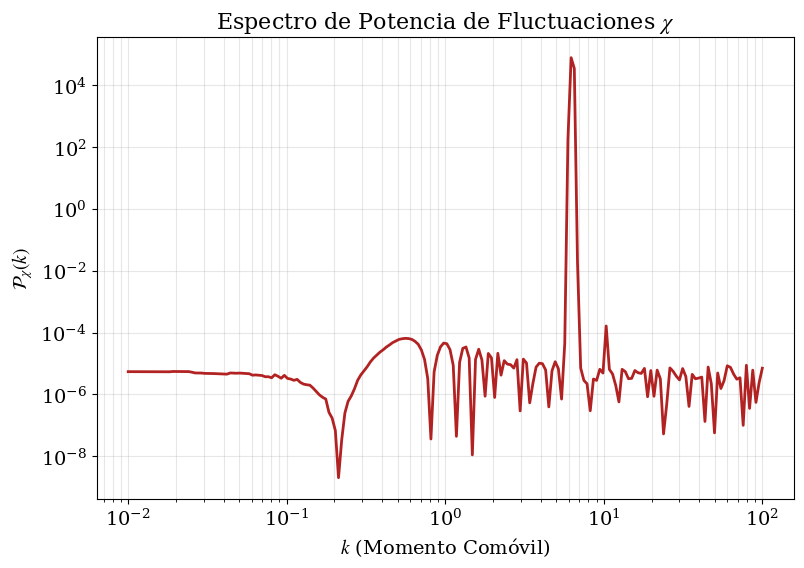

In [13]:
# Calculo P_chi para cada k usando los valores finales guardados
P_chi_vals = [Pchi(chi_val, k_val) for chi_val, k_val in zip(chi_values, ks)]

# Grafico
plt.figure(figsize=(9, 6))
plt.plot(ks, P_chi_vals/(ks**3), lw=2, color='firebrick')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k$ (Momento Comóvil)', fontsize=14)
plt.ylabel(r'$\mathcal{P}_{\chi}(k)$', fontsize=14)
plt.title(r'Espectro de Potencia de Fluctuaciones $\chi$', fontsize=16)
plt.grid(True, which="both", alpha=0.3)
plt.show()

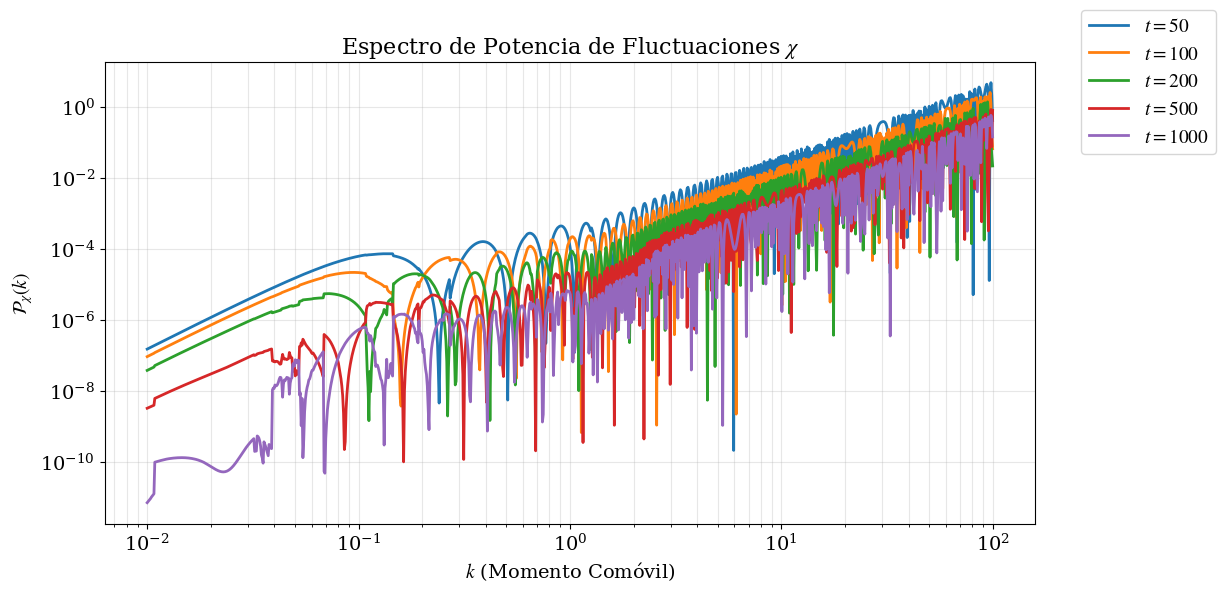

In [ ]:
# Parámetros
g = 0.1
n_k = 1000
ks = np.logspace(-2, 2, n_k)
chi_values = np.zeros(n_k)

plt.figure(figsize=(12, 6))

ts = (50, 100, 200, 500, 1000)
for t in ts:
    t_span = (0, t)
    for i, k in enumerate(ks):
        # Condiciones iniciales
        phi0 = 1.0
        phi_dot0 = phi0**2/np.sqrt(2)
        areh = 1.0
        areh_dot = np.sqrt((1/3) * (0.5 * phi_dot0**2 + 0.25 * phi0**4))
        
        # Perturbaciones
        Omega_chi = np.sqrt(k**2/areh**2 + g**2 * phi0**2)
        chi_k0 = 1.0 / np.sqrt(2 * Omega_chi)
        chi_dot_k0 = 0.0
        
        y0 = [phi0, phi_dot0, chi_k0, chi_dot_k0, areh, areh_dot] 

        sol_k = solve_ivp(pert_exp, t_span, y0, args=(k, g), method='RK45')
        
        # Guardamos solo el valor final del modo chi_k
        chi_values[i] = sol_k.y[2, -1]

    # Calculo P_chi para cada k usando los valores finales guardados
    P_chi_vals = [Pchi(chi_val, k_val) for chi_val, k_val in zip(chi_values, ks)]

    # Grafico
    plt.plot(ks, P_chi_vals, lw=2, label=rf'$t={t}$')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$k$ (Momento Comóvil)', fontsize=14)
plt.ylabel(r'$\mathcal{P}_{\chi}(k)$', fontsize=14)
plt.title(r'Espectro de Potencia de Fluctuaciones $\chi$', fontsize=16)
plt.grid(True, which="both", alpha=0.3)
plt.legend(loc = (1.05, 0.8))
plt.show()

# GW Production

Para poder calcular la densidad de energía de ondas gravitacionales debemos utilizar

$$\frac{d \rho_{GW}}{d \log k} = \frac{k^3}{16 \pi^4 m_p^2 a^4} \int p^6 \sin^5 \theta ~ \left\{ \left[ I_{(c)} (k, p, \theta, \tau)  \right]^2 + \left[ I_{(s)} (k, p, \theta, \tau)  \right]^2 \right\} ~ dp ~ d\theta$$

dónde $I_{(s)}$ e $I_{(c)}$ están definidas a partir de

$$I_{(c)} (k, p, \theta, \tau) = \int_{\tau_{i}}^\tau  \frac{\cos (k\tau^\prime)}{a \left( \tau^\prime \right)} ~ \chi^{(c)}_{p} (\tau^\prime) ~ \chi_{k - p}^{(c) *} (\tau^\prime) ~ d\tau^\prime$$

$$I_{(s)} (k, p, \theta, \tau) = \int_{\tau_{i}}^\tau  \frac{\sin (k\tau^\prime)}{a \left( \tau^\prime \right)} ~ \chi^{(c)}_{p} (\tau^\prime) ~ \chi_{k - p}^{(c) *} (\tau^\prime) ~ d\tau^\prime$$

y los $\chi_k^{(c)}$ es la dinámica del campo hijo que conseguimos previamente

Recordar: $\left| \vec{k} - \vec{p} \right|^2 = k^2 + p^2 - 2 k p \cos \theta$

## Prueba 1

In [17]:
def pert(z, y, ks, q):
    phi, phi_dot, a, a_dot = y[:4]
    
    # Evolución de a(t)
    a_ddot = - a/3 * (phi_dot**2 - phi**4/4)
    H = a_dot/a
    
    # Ecuación para φ
    phi_ddot = -3 * H * phi_dot - phi **3

    
    dy = [phi_dot, phi_ddot, a_dot, a_ddot]
    
    # Modos de chi
    start = 4
    for k in ks:
        chi = y[start]
        chi_p = y[start+1]
        chi_pp = -(k**2 + q * phi**2) * chi
        dy.extend([chi_p, chi_pp])
        start += 2
    return dy

In [18]:
# Parámetros
Lambda = 9e-14
q = 100              
g = np.sqrt(q * Lambda)
z_max = 50                 # Tiempo máximo adimensional

# Definimos los momentos k
kappa_max = 10 * q**0.25
kappas = np.linspace(0.01, kappa_max, 100)

# Condiciones iniciales
phi0 = 1         
phi_dot0 = phi0**2/np.sqrt(2)
areh = 1.0
a_dot_reh = areh * phi0**2/(np.sqrt(6))
y0 = [phi0, phi_dot0, areh, a_dot_reh]
# Modos (Vacío)
for k in kappas:
    y0.extend([1.0/np.sqrt(2*k), 0.0])

In [19]:
# Resolvemos
sol = solve_ivp(pert, [0, z_max], y0, args=(kappas, q), t_eval=np.linspace(0, z_max, 1000), method='RK45')

# Calculamos el espectro de GW
z = sol.t
phi = sol.y[0]
a = sol.y[2]

spectrum = []
for i, k in enumerate(kappas):
    chi_k = sol.y[4 + 2*i]
    
    source = (chi_k**2) / a 
    Ic = simpson(y=np.cos(k * z) * source, x=z)
    Is = simpson(y=np.sin(k * z) * source, x=z)
    
    power = k**3 * (Ic**2 + Is**2) 
    spectrum.append(power)

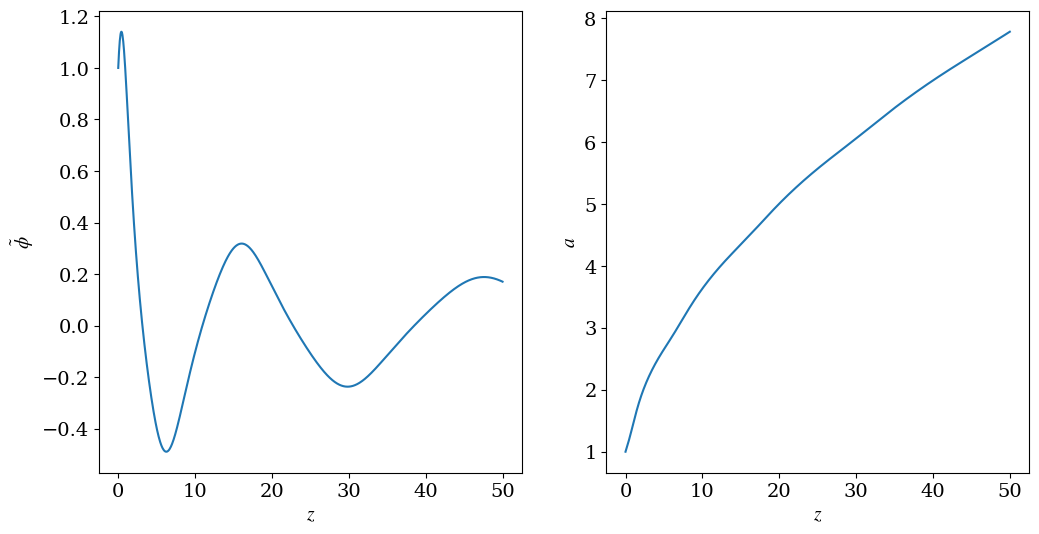

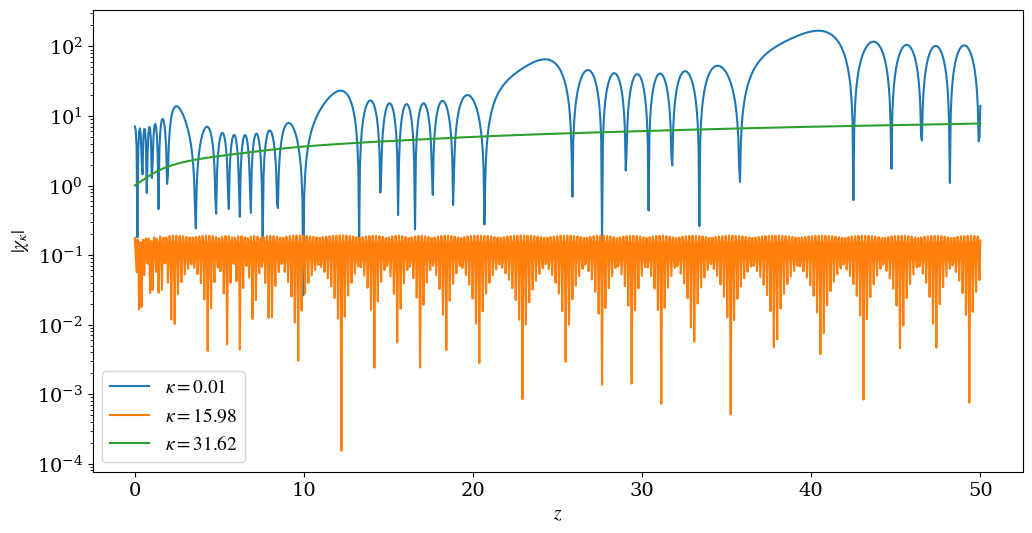

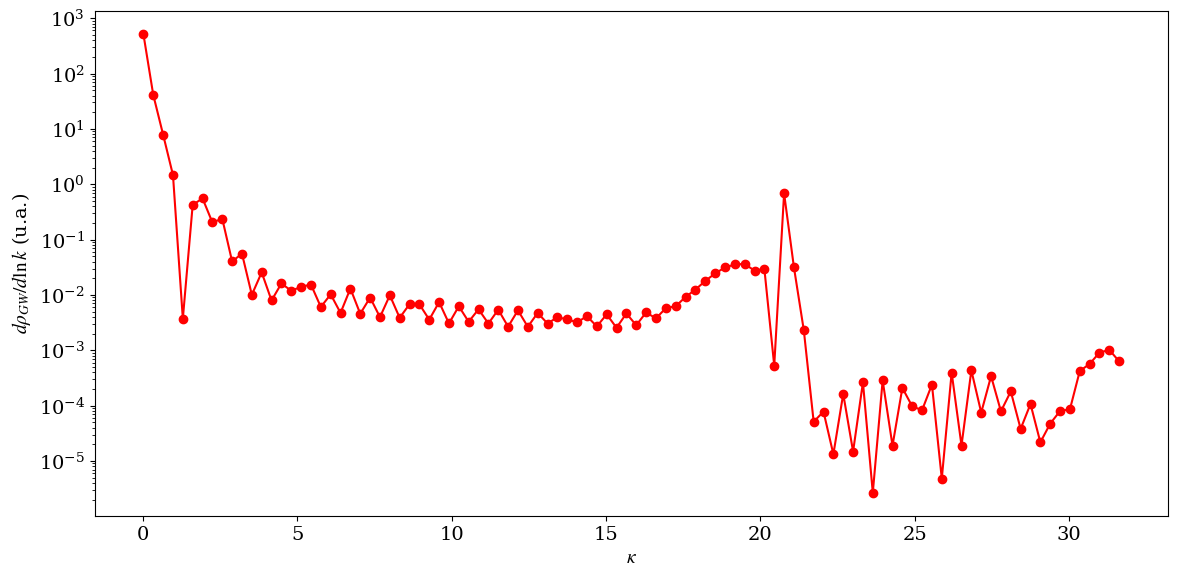

In [20]:
# Plot 1: Evolución del background
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(z, sol.y[0])
plt.xlabel("$z$")
plt.ylabel(r"$\tilde{\phi}$")

plt.subplot(1, 2, 2)
plt.plot(z, sol.y[2])
plt.xlabel("$z$")
plt.ylabel(r"$a$")

# Plot 2: Modos \chi_k
plt.figure(figsize=(12, 6))

for i in [0, len(kappas)//2, -1]:
    plt.plot(z, np.abs(sol.y[4 + 2*i]), label=f"$\kappa={kappas[i]:.2f}$")

plt.yscale('log')
plt.xlabel("$z$")
plt.ylabel(r"$|\chi_\kappa|$")
plt.legend()

# Plot 3: Espectro de GW
plt.figure(figsize=(12, 6))

plt.plot(kappas, spectrum, 'o-', color='red')
plt.xlabel("$\kappa$")
plt.ylabel(r"$d\rho_{GW}/d\ln k$ (u.a.)")
plt.yscale('log')

plt.tight_layout()
plt.show()

## Prueba 2

In [8]:
def perturbation_lphi4(t, y, k, q):
    phi, phi_dot, chi_k, chi_dot_k = y
    phi_ddot = - phi**3
    chi_ddot_k = - (k**2 + q * phi**2) * chi_k
    return [phi_dot, phi_ddot, chi_dot_k, chi_ddot_k]

def pert_exp(t, y, k, g):
    phi, phi_dot, chi_k, chi_dot_k, a, a_dot = y

    # Evolución de a(t)
    a_ddot = - a/3 * (phi_dot**2 - phi**4/4)
    H = a_dot/a
    
    # Ecuación para φ
    phi_ddot = -3 * H * phi_dot - phi **3
    
    # Ecuaciones para χ_k
    chi_ddot_k = - 3 * H * chi_dot_k - (k ** 2 / a**2 + g**2 * phi**2) * chi_k 
    
    return [phi_dot, phi_ddot, chi_dot_k, chi_ddot_k, a_dot, a_ddot]

def Is(ti, tf, y0, k, g, p, x):
    t_eval = np.linspace(ti, tf, int(1e4))
    
    sol_k = solve_ivp(perturbation_lphi4, [ti, tf], y0, args=(k, g), t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-8)
    chi_k = sol_k.y[2]
    a = 1#sol_k.y[4]

    kp = np.sqrt(k**2 + p**2 - 2 * k * p * x)
    sol_p = solve_ivp(perturbation_lphi4, [ti, tf], y0, args=(kp, g), t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-8)
    chi_p = sol_p.y[2]
    
    # Interpolación usando sol_k.t (no t_eval)
    #a_interp = interp1d(sol_k.t, a, kind='linear', bounds_error=False, fill_value=0)
    chi_k_interp = interp1d(sol_k.t, chi_k, kind='linear', bounds_error=False, fill_value=0)
    chi_p_interp = interp1d(sol_p.t, chi_p, kind='linear', bounds_error=False, fill_value=0)  # Usa sol_p.t para chi_p
    
    def integrand(t):
        return np.sin(k*t) / a * chi_k_interp(t) * chi_p_interp(t) #np.sin(k*t) / a_interp(t) * chi_k_interp(t) * chi_p_interp(t)

    Is_value, _ = quad(integrand, ti, tf)
    return Is_value

def Ic(ti, tf, y0, k, g, p, x):
    t_eval = np.linspace(ti, tf, int(1e4))
    
    sol_k = solve_ivp(perturbation_lphi4, [ti, tf], y0, args=(k, g), t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-8)
    chi_k = sol_k.y[2]
    a = 1#sol_k.y[4]

    kp = np.sqrt(k**2 + p**2 - 2 * k * p * x)
    sol_p = solve_ivp(perturbation_lphi4, [ti, tf], y0, args=(kp, g), t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-8)
    chi_p = sol_p.y[2]
    
    # Interpolación
    #a_interp = interp1d(sol_k.t, a, kind='linear', bounds_error=False, fill_value=0)
    chi_k_interp = interp1d(sol_k.t, chi_k, kind='linear', bounds_error=False, fill_value=0)
    chi_p_interp = interp1d(sol_p.t, chi_p, kind='linear', bounds_error=False, fill_value=0)
    
    def integrand(t):
        return np.cos(k*t) / a * chi_k_interp(t) * chi_p_interp(t) #np.cos(k*t) / a_interp(t) * chi_k_interp(t) * chi_p_interp(t)

    Ic_value, _ = quad(integrand, ti, tf)
    return Ic_value

def rhoGW(ti, tf, y0, k, g, p0, pf):
    def integrand(p, x):
        Is_value = Is(ti, tf, y0, k, g, p, x)
        Ic_value = Ic(ti, tf, y0, k, g, p, x)
        return p**6 * (1 - x**2)**2 * (np.abs(Is_value)**2 + np.abs(Ic_value)**2)
    
    rhoGW_value, _ = dblquad(integrand, -1, 1, lambda x: p0, lambda x: pf)  # Nota: límites de x de -1 a 1, p de p0 a pf
    return rhoGW_value

Calculando rhoGW: 100%|██████████| 20/20 [1:00:43<00:00, 182.17s/it]
/tmp/ipykernel_50323/4225682881.py:29: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


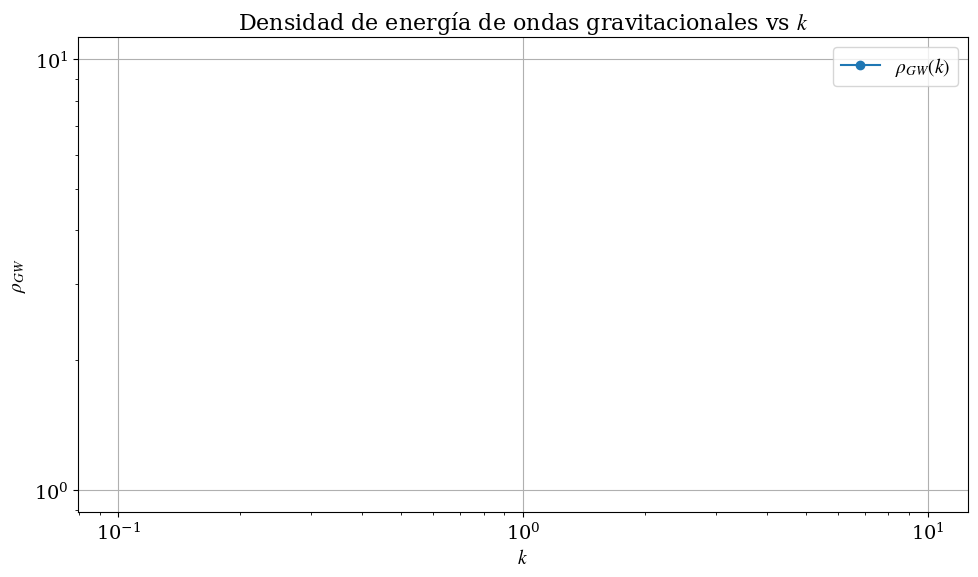

In [9]:
# Parámetros fijos
ti, tf = 0, 100
g = 5050
p0, pf = 0, 10  
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2 / np.sqrt(2)
#a0 = 1
#a_dot0 = phi0 / np.sqrt(3)
y0 = [phi0, phi_dot0, 0, 0]#, a0, a_dot0]  # CI: phi, phi_dot, chi_k, chi_dot_k, a, a_dot

# Rango de k
k_values = np.logspace(-1, 1, 20)  
rhoGW_values = []

for k in tqdm(k_values, desc="Calculando rhoGW"):
    rho = rhoGW(ti, tf, y0, k, g, p0, pf)
    rhoGW_values.append(rho)

rhoGW_values = np.array(rhoGW_values)

# Graficar
plt.figure(figsize=(10, 6))
plt.loglog(k_values, rhoGW_values, 'o-', label=r'$\rho_{GW}(k)$')
plt.xlabel(r'$k$', fontsize=14)
plt.ylabel(r'$\rho_{GW}$', fontsize=14)
plt.title(r'Densidad de energía de ondas gravitacionales vs $k$', fontsize=16)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Prueba 3

Calculando Espectro GW: 100%|██████████| 100/100 [1:11:27<00:00, 42.87s/it]


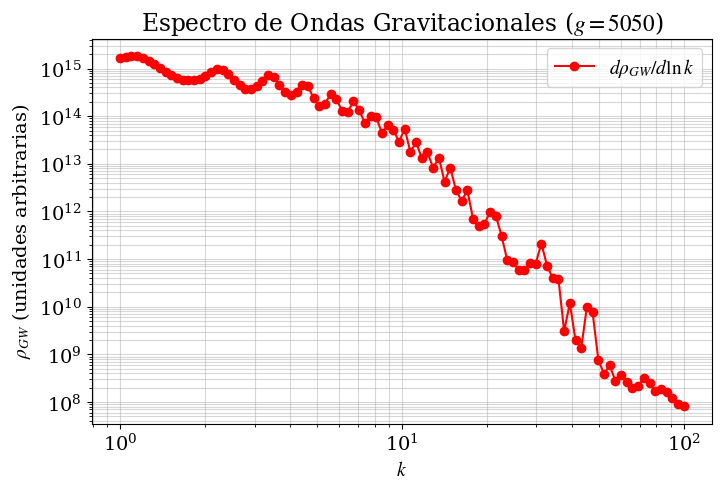

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, quad, simpson
from scipy.interpolate import RegularGridInterpolator
from tqdm import tqdm

def solve_system(k_grid, t_span, phi0, phi_dot0, g):
    """
    Evoluciona el fondo y un grid de modos chi_k simultáneamente.
    """
    # El vector y tendrá: [phi, phi_dot, chi_k1, chi_dot_k1, chi_k2, chi_dot_k2, ...]
    n_k = len(k_grid)
    
    def odes(t, y):
        phi = y[0]
        phi_dot = y[1]
        chis = y[2::2]
        chi_dots = y[3::2]
        
        phi_ddot = - phi**3
        # Ecuación para cada modo chi_k: d2chi/dt2 + (k^2 + g^2 phi^2) chi = 0
        chi_ddots = - (k_grid**2 + g**2 * phi**2) * chis
        
        # Reensamblar derivadas
        derivatives = np.zeros_like(y)
        derivatives[0] = phi_dot
        derivatives[1] = phi_ddot
        derivatives[2::2] = chi_dots
        derivatives[3::2] = chi_ddots
        return derivatives

    # CI para chi_k: Aproximación de Bunch-Davies (fluctuaciones de vacío)
    # chi ~ 1/sqrt(2k). Para evitar singularidad en k=0, usamos un pequeño regulador.
    y0 = np.zeros(2 + 2 * n_k)
    y0[0] = phi0
    y0[1] = phi_dot0
    y0[2::2] = 1.0 / np.sqrt(2 * np.maximum(k_grid, 0.1)) # Amplitud inicial
    y0[3::2] = 0 # Velocidad inicial

    sol = solve_ivp(odes, t_span, y0, method='RK45', rtol=1e-6, atol=1e-6)
    return sol

def calculate_gw_spectrum(k_obs, k_grid, t_eval, chi_matrix, g):
    """
    Calcula rho_GW para un conjunto de modos k_obs usando el grid ya resuelto.
    """
    # chi_matrix tiene forma (n_k, n_t)
    # Creamos un interpolador para chi(k, t)
    chi_interp = RegularGridInterpolator((k_grid, t_eval), chi_matrix, 
                                          bounds_error=False, fill_value=0)
    
    rho_values = []
    
    # Pre-calculamos integrales de tiempo para cada par (p, kp) es muy lento
    # Simplificación para el ejemplo: integral de convolución
    for k in tqdm(k_obs, desc="Calculando Espectro GW"):
        
        def integrand_convolucion(p, x):
            # kp = |k - p|
            kp = np.sqrt(k**2 + p**2 - 2*k*p*x)
            
            # Obtenemos las trayectorias temporales interpoladas
            chi_p = chi_interp(np.column_stack((np.full_like(t_eval, p), t_eval)))
            chi_kp = chi_interp(np.column_stack((np.full_like(t_eval, kp), t_eval)))
            
            source = chi_p * chi_kp
            
            # Integrales de la función de Green (Sin y Cos)
            Is = simpson(y=np.sin(k * t_eval) * source, x=t_eval)
            Ic = simpson(y=np.cos(k * t_eval) * source, x=t_eval)
            
            return p**6 * (1 - x**2)**2 * (Is**2 + Ic**2)

        # Integración sobre p (momento interno) y x (coseno del ángulo)
        # Ajustamos límites de p según el grid disponible
        p_min, p_max = k_grid[0], k_grid[-1]
        
        # Nota: En una simulación real esto es una integral doble pesada.
        # Aquí usamos una discretización manual para ganar velocidad.
        ps = np.linspace(p_min, p_max, 30)
        xs = np.linspace(-1, 1, 10)
        
        res_p = 0
        for p in ps:
            for x in xs:
                res_p += integrand_convolucion(p, x)
        
        rho_values.append(res_p)
        
    return np.array(rho_values)

# --- PARÁMETROS ---
g = 5050  
phi0 = 1.0 / np.sqrt(np.pi)
phi_dot0 = phi0**2 / np.sqrt(2)
t_max = 50
k_grid = np.logspace(-2, 2, 100) # Grid de modos para resolver la física

# 1. Evolución de campos
sol = solve_system(k_grid, [0, t_max], phi0, phi_dot0, g)
t_eval = sol.t
chi_matrix = sol.y[2::2] # Extraer solo las chi_k

# 2. Espectro de GW (para un subconjunto de k)
k_target = np.logspace(-2, 2, 100)
rho_gw = calculate_gw_spectrum(k_target, k_grid, t_eval, chi_matrix, g)

# 3. Graficar
plt.figure(figsize=(8, 5))
plt.loglog(k_target, rho_gw, 'r-o', label=r'$d\rho_{GW}/d\ln k$')
plt.xlabel('$k$')
plt.ylabel(r'$\rho_{GW}$ (unidades arbitrarias)')
plt.title(f'Espectro de Ondas Gravitacionales ($g={g}$)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

## Prueba 4

spectrum_gw: [1.38373457e-07 0.00000000e+00 0.00000000e+00 0.00000000e+00
 8.63795566e-08 0.00000000e+00 0.00000000e+00 5.08602371e-08
 5.26755097e-08 0.00000000e+00 0.00000000e+00 3.89504027e-08
 0.00000000e+00 1.61005976e-08 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000

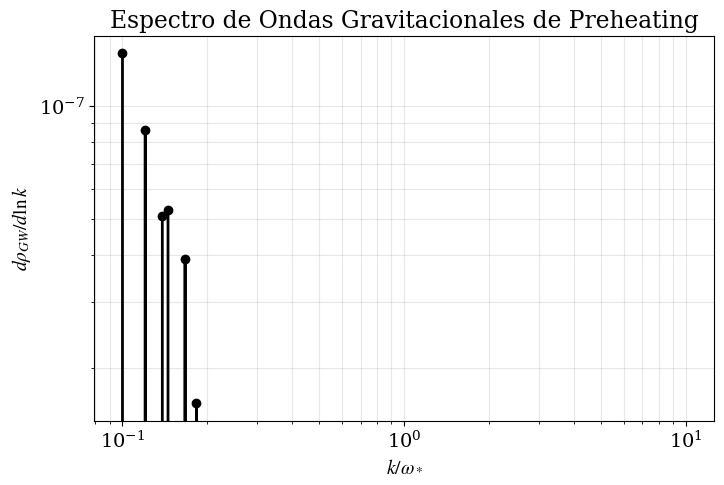

In [13]:
from scipy.integrate import trapezoid, solve_ivp
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt

def pert_exp(t, y, k, g):
    phi, phi_dot, chi_k, chi_dot_k, a, a_dot = y
    if a == 0:
        a_ddot = 0
        H = 0
    else:
        a_ddot = -a / 3 * (phi_dot**2 - phi**4 / 4)
        H = a_dot / a
    phi_ddot = -3 * H * phi_dot - phi**3
    chi_ddot_k = -3 * H * chi_dot_k - (k**2 / (a**2 if a != 0 else 1) + g**2 * phi**2) * chi_k
    return [phi_dot, phi_ddot, chi_dot_k, chi_ddot_k, a_dot, a_ddot]

def solve_for_k(k, g, ti, tf, t_eval, y0_full):
    if np.any(np.isnan(y0_full)) or np.any(np.isinf(y0_full)):
        raise ValueError(f"y0 para k={k} contiene NaN/Inf")
    sol = solve_ivp(pert_exp, [ti, tf], y0_full, args=(k, g), t_eval=t_eval, method='RK45', rtol=1e-6, atol=1e-8)
    if not sol.success:
        raise ValueError(f"Solve failed for k={k}: {sol.message}")
    if sol.y.shape[0] != 6:
        raise ValueError(f"sol.y shape incorrect for k={k}: {sol.y.shape}")
    return sol

def calculate_rho_GW_spectrum(sol, ks, g):
    t = np.array(sol.t)
    a = sol.y[4]
    chis = {k: interp1d(t, sol.y[2 + 2*i], kind='linear', fill_value=0) for i, k in enumerate(ks)}
    a_interp = interp1d(t, a, kind='linear', fill_value=0)
    
    ps = ks
    xs = np.linspace(-0.99, 0.99, 20)
    d_rho_dln_k = np.zeros(len(ks))
    
    for i, k in enumerate(ks):
        sum_p_vals = []
        for p in ps:
            sum_x_vals = []
            for x in xs:
                arg = k**2 + p**2 - 2*k*p*x
                if arg < 0: continue
                kp_mag = np.sqrt(arg)
                idx_kp = np.abs(ks - kp_mag).argmin()
                source = (chis[p](t) * chis[ks[idx_kp]](t)) / a_interp(t)
                Is = trapezoid(np.sin(k * t) * source, t)
                Ic = trapezoid(np.cos(k * t) * source, t)
                factor_geom = p**6 * (1 - x**2)**2
                sum_x_vals.append(factor_geom * (Is**2 + Ic**2))
            sum_p_vals.append(np.sum(sum_x_vals))
        d_rho_dln_k[i] = k**3 * trapezoid(sum_p_vals, ps)
    
    return ks, d_rho_dln_k

# Parámetros
g = 5050
ks = np.logspace(-1, 1, 100)
ti, tf = 0, 50
t_eval = np.linspace(ti, tf, 200)

phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2 / np.sqrt(2)
a0 = 1
a_dot0 = phi0 / np.sqrt(3)
y0_full = [phi0, phi_dot0, 0, 0, a0, a_dot0]

# Resolver
sols = {}
for k in ks:
    sols[k] = solve_for_k(k, g, ti, tf, t_eval, y0_full)

# Combinar en sol
combined_y = [sols[ks[0]].y[0], sols[ks[0]].y[1], sols[ks[0]].y[2], sols[ks[0]].y[3], sols[ks[0]].y[4], sols[ks[0]].y[5]]
for k in ks[1:]:
    combined_y.extend([sols[k].y[2], sols[k].y[3]])

class CombinedSol:
    def __init__(self, t, y):
        self.t = t
        self.y = np.array(y)

sol = CombinedSol(t_eval, combined_y)

# Calcular
ks_gw, spectrum_gw = calculate_rho_GW_spectrum(sol, ks, g)
print("spectrum_gw:", spectrum_gw)

# Graficar
plt.figure(figsize=(8, 5))
plt.loglog(ks_gw, spectrum_gw, "-o", color='black', lw=2)
plt.xlabel(r'$k / \omega_*$')
plt.ylabel(r'$d\rho_{GW} / d\ln k$')
plt.title('Espectro de Ondas Gravitacionales de Preheating')
plt.grid(True, which="both", alpha=0.3)
plt.show()

## Prueba 5

In [ ]:
def solve_fields(t_span, ks, g, y0_background):
    def system(t, y, ks, g):
        phi, phi_dot, a, a_dot = y[0:4]
        chis = y[4::2]
        chi_dots = y[5::2]
        H = a_dot / a
        phi_ddot = -3 * H * phi_dot - phi**3
        a_ddot = - a/3 * (phi_dot**2 - phi**4/4)
        chi_ddots = - 3 * H * chi_dots - (ks**2 / a**2 + g**2 * phi**2) * chis
        
        dy = np.zeros_like(y)
        dy[0:4] = [phi_dot, phi_ddot, a_dot, a_ddot]
        dy[4::2], dy[5::2] = chi_dots, chi_ddots
        return dy

    # Construir vector y0 completo
    y0 = list(y0_background)
    for k in ks:
        omega = np.sqrt(k**2 + g**2 * y0_background[0]**2)
        y0.extend([1.0/np.sqrt(2*omega), 0.0])
    
    sol = solve_ivp(system, t_span, y0, args=(ks, g), method='RK45', rtol=1e-6)
    return sol

def calculate_gw_spectrum(sol, ks, g):
    t = sol.t
    a = sol.y[2]
    chi_data = {}
    for i, k in enumerate(ks):
        chi_data[k] = interp1d(t, sol.y[4 + 2*i], kind='cubic')
    
    a_interp = interp1d(t, a, kind='cubic')
    
    def get_I(k, p, x, func_type='sin'):
        kp = np.sqrt(k**2 + p**2 - 2*k*p*x)
        # Aproximamos kp al valor más cercano en nuestro grid de ks
        kp_idx = np.abs(ks - kp).argmin()
        kp_val = ks[kp_idx]
        
        # Integrando: sin/cos(k*tau) * chi_k * chi_kp / a
        kernel = np.sin(k*t) if func_type == 'sin' else np.cos(k*t)
        integrando = (kernel / a) * chi_data[k](t) * chi_data[kp_val](t)
        return simpson(integrando, t)

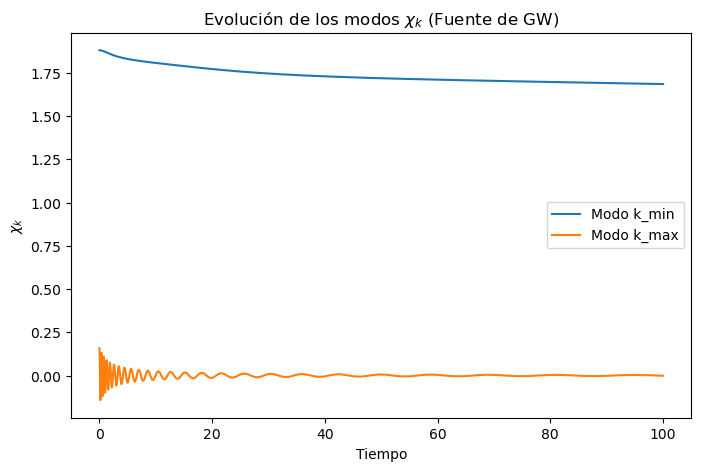

In [1]:
import numpy as np
from scipy.integrate import solve_ivp, simpson
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# 1. Resolver la evolución de todos los campos primero
def solve_all_fields(t_span, ks, g, y0_background):
    def system(t, y, ks, g):
        phi, phi_dot, a, a_dot = y[0:4]
        chis = y[4::2]
        chi_dots = y[5::2]
        H = a_dot / a
        phi_ddot = -3 * H * phi_dot - phi**3
        a_ddot = - a/3 * (phi_dot**2 - phi**4/4)
        chi_ddots = - 3 * H * chi_dots - (ks**2 / a**2 + g**2 * phi**2) * chis
        
        dy = np.zeros_like(y)
        dy[0:4] = [phi_dot, phi_ddot, a_dot, a_ddot]
        dy[4::2], dy[5::2] = chi_dots, chi_ddots
        return dy

    # Construir vector y0 completo
    y0 = list(y0_background)
    for k in ks:
        omega = np.sqrt(k**2 + g**2 * y0_background[0]**2)
        y0.extend([1.0/np.sqrt(2*omega), 0.0])
    
    sol = solve_ivp(system, t_span, y0, args=(ks, g), method='RK45', rtol=1e-6)
    return sol

# 2. Función para calcular el espectro de GW
def calculate_gw_spectrum(sol, ks, g):
    t = sol.t
    a = sol.y[2]
    # Diccionario de funciones interpoladas para cada k
    # Esto evita resolver la ODE miles de veces
    chi_data = {}
    for i, k in enumerate(ks):
        chi_data[k] = interp1d(t, sol.y[4 + 2*i], kind='cubic')
    
    a_interp = interp1d(t, a, kind='cubic')
    
    def get_I(k, p, x, func_type='sin'):
        kp = np.sqrt(k**2 + p**2 - 2*k*p*x)
        # Aproximamos kp al valor más cercano en nuestro grid de ks
        kp_idx = np.abs(ks - kp).argmin()
        kp_val = ks[kp_idx]
        
        # Integrando: sin/cos(k*tau) * chi_k * chi_kp / a
        # Nota: tau es tiempo conforme o t según tu métrica
        kernel = np.sin(k*t) if func_type == 'sin' else np.cos(k*t)
        integrando = (kernel / a) * chi_data[k](t) * chi_data[kp_val](t)
        return simpson(integrando, t)

    # Aquí calcularías la integral doble sobre p y x para un k dado
    # rho_GW(k) ~ k^3 * integral( p^6 * (1-x^2)^2 * |I|^2 dp dx )
    # (Este paso es intensivo, se recomienda usar un grid de p y x precalculado)
    return chi_data

# --- Configuración y Ejecución ---
g = 0.1
ks = np.linspace(0.1, 20, 50) # Grid de momentos
y0_bg = [1.0, 0.0, 1.0, 0.57] # phi, phi_dot, a, a_dot

sol = solve_all_fields([0, 100], ks, g, y0_bg)

# Visualización del campo de partículas (fuente de las GW)
plt.figure(figsize=(8,5))
plt.plot(sol.t, sol.y[4], label='Modo k_min')
plt.plot(sol.t, sol.y[-2], label='Modo k_max')
plt.title("Evolución de los modos $\chi_k$ (Fuente de GW)")
plt.xlabel("Tiempo"); plt.ylabel("$\chi_k$")
plt.legend(); plt.show()

In [ ]:
from scipy.integrate import trapz, solve_ivp
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt

def solve_for_k(k, g, ti, tf, t_eval, y0_bg):
    y0_full = y0_bg + [0, 0]  # phi, phi_dot, a, a_dot, chi_k, chi_dot_k
    sol = solve_ivp(pert_exp, [ti, tf], y0_full, args=(k, g), t_eval=t_eval, method='RK45', rtol=1e-6, atol=1e-8)
    return sol

# Función del espectro GW
def calculate_rho_GW_spectrum(sol, ks, g):
    t = sol.t
    a = sol.y[2]  # Índice de a(t)
    chis = {k: interp1d(t, sol.y[4 + 2*i], kind='linear', fill_value=0) for i, k in enumerate(ks)}
    a_interp = interp1d(t, a, kind='linear', fill_value=0)
    
    ps = ks
    xs = np.linspace(-0.99, 0.99, 50)
    d_rho_dln_k = np.zeros(len(ks))
    
    for i, k in enumerate(ks):
        sum_p_vals = []
        for p in ps:
            sum_x_vals = []
            for x in xs:
                arg = k**2 + p**2 - 2*k*p*x
                if arg < 0: continue
                kp_mag = np.sqrt(arg)
                idx_kp = np.abs(ks - kp_mag).argmin()
                source = (chis[p](t) * chis[ks[idx_kp]](t)) / a_interp(t)
                Is = trapz(np.sin(k * t) * source, t)
                Ic = trapz(np.cos(k * t) * source, t)
                factor_geom = p**6 * (1 - x**2)**2
                sum_x_vals.append(factor_geom * (Is**2 + Ic**2))
            sum_p_vals.append(np.sum(sum_x_vals))
        d_rho_dln_k[i] = k**3 * trapz(sum_p_vals, ps)
    
    return ks, d_rho_dln_k

# Parámetros
g = 1e-2
ks = np.logspace(-1, 1, 5) 
ti, tf = 0, 100
t_eval = np.linspace(ti, tf, 500)

# Condiciones iniciales background
phi0 = 1/np.sqrt(np.pi)
phi_dot0 = phi0**2 / np.sqrt(2)
a0 = 1
a_dot0 = phi0 / np.sqrt(3)
y0_bg = [phi0, phi_dot0, a0, a_dot0]

# Resolver para cada k
sols = {}
for k in ks:
    sols[k] = solve_for_k(k, g, ti, tf, t_eval, y0_bg)

# Combinar en sol
combined_y = [sols[ks[0]].y[0], sols[ks[0]].y[1], sols[ks[0]].y[2], sols[ks[0]].y[3]]
for k in ks:
    combined_y.extend([sols[k].y[4], sols[k].y[5]])

class CombinedSol:
    def __init__(self, t, y):
        self.t = t
        self.y = np.array(y)

sol = CombinedSol(t_eval, combined_y)

# Calcular espectro
ks_gw, spectrum_gw = calculate_rho_GW_spectrum(sol, ks, g)

# Graficar
plt.figure(figsize=(8, 5))
plt.loglog(ks_gw, spectrum_gw, color='black', lw=2)
plt.xlabel(r'$k / \omega_*$')
plt.ylabel(r'$d\rho_{GW} / d\ln k$')
plt.title('Espectro de Ondas Gravitacionales de Preheating')
plt.grid(True, which="both", alpha=0.3)
plt.show()

/tmp/ipykernel_1359283/2536804721.py:10: RuntimeWarning: invalid value encountered in scalar divide
  H = a_dot/a
/tmp/ipykernel_1359283/2536804721.py:16: RuntimeWarning: divide by zero encountered in scalar divide
  chi_ddot_k = - 3 * H * chi_dot_k - (k ** 2 / a**2 + g**2 * phi**2) * chi_k
